In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import logging
import os
import warnings
import itertools
from datetime import datetime, timedelta
from functools import partial
from pathlib import Path
from optimization_engines import (
    equal_weights_baseline, 
    genetic_algorithm_sharpe, 
    scipy_minimize_sharpe, 
    riskfolio_sharpe_optimized, 
)

SEED = 12
np.random.seed(SEED)
msg_level = logging.INFO
# Suppress all RuntimeWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Portfolio Optimization using multiple engines

In [39]:
# Create a logger
logger = logging.getLogger("inspect_results_logger")
logger.setLevel(msg_level)  # Set the level for this logger

# Create a handler (where to send the logs)
handler = logging.StreamHandler()  # Send to the console
handler.setLevel(msg_level)

# Create a formatter (how to format the logs)
formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")
handler.setFormatter(formatter)

# Add the handler to the logger
logger.addHandler(handler)

### Path definition

In [40]:
benchmark_path = '../../data/benchmark_gspc.pkl'
source_path = '../../data/stocks_adjclose.pkl'

### Data loading

Ticker,ds,^GSPC
0,2011-01-03,1271.869995
1,2011-01-04,1270.199951
2,2011-01-05,1276.560059
3,2011-01-06,1273.849976
4,2011-01-07,1271.500000


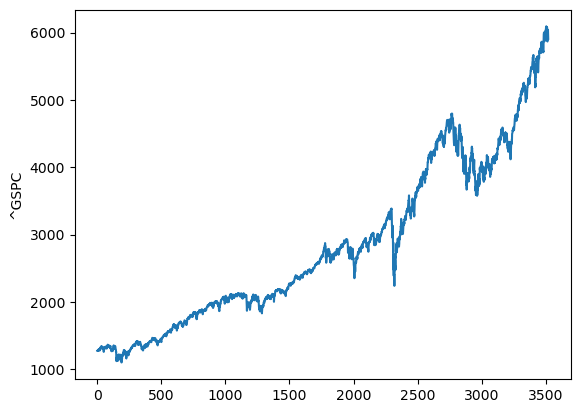

In [41]:
benchmark = pd.read_pickle(benchmark_path)
sns.lineplot(benchmark['^GSPC'])
benchmark.head()

In [42]:
source = pd.read_pickle(source_path)
print(source.shape)
# Check if any row contains at least one NaN
#print(source_wide.isnull().any(axis=1))
# Check if any value in the DataFrame is null
has_any_nan = source.isnull().values.any()
print("Any NaN in source_wide:", has_any_nan)
source.head()

(3522, 439)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WRB,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,6.112024,18.971697,71.104691,11.828708,76.192101,14.700940,43.098133,26.977388,47.841393,38.200001
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,6.072278,18.631702,69.911537,11.702991,78.568939,14.763333,43.300457,26.565216,47.206047,37.840000
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,6.045782,18.713308,70.882263,12.068158,79.582596,14.675976,43.184826,26.691620,47.240875,37.799999
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,5.977333,18.577297,71.084503,11.984348,80.162842,14.663502,43.462337,26.878460,45.778728,37.480000
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,5.939793,18.486635,70.963158,12.313586,83.001091,14.794533,43.699345,27.213682,45.770027,37.599998


### Porfolio Stats

In [43]:
def portfolio_stats(weights, data):

    weights = np.array(weights)
    returns = np.log(data) - np.log(data.shift(1)) # log return to minimize fp error
    # CONSISTENT: Always use log returns, never pct_change()
    port_return = np.sum(returns.mean() * weights) 
    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() , weights)))
    try:
        sharpe_ratio = port_return/port_vol
    except Exception as e:
        sharpe_ratio = 0
    return sharpe_ratio, port_return, port_vol

### Fitness function

In [44]:
def fitness_function(weights, data):
    sharpe_ratio, _, _ = portfolio_stats(weights, data)
    return sharpe_ratio


In [45]:
def curried_fitness(weights, data):
    port_return = partial(fitness_function, data)
    return port_return

def minimize_sharpe(weights):
    return -1 * curried_fitness(weights)

### Data generator

Data generator to instantiate blocks on demand

In [46]:
def generate_data(df, benchmark, days_to_avg=30, days_to_opt=30, seed=SEED):
    df2 = df.reset_index()
    benchmark2 = benchmark.reset_index()
    elements = df2.sample(n=100, random_state=seed).index # definint a maximum of 100 different sampled initial dates
    for idx in elements:
        df_sample = df2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample = df_sample.set_index('ds')
        df_sample_b = benchmark2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample_b = df_sample_b.set_index('ds').drop(['index'], axis=1)
        yield df_sample, df_sample_b

### Backtest

In [47]:
def backtest(optimization_function, data, benchmark, initial_capital, avg_period, opt_period):
    portfolio_value = initial_capital
    portfolio_returns = []
    benchmark_returns = []
    portfolio_total_return = []
    portfolio_sharpe_ratios = []
    weights_history = pd.DataFrame(index=data.index, columns=data.columns)
    portfolio_value_history = pd.Series(index=data.index, name='Portfolio Value', dtype='float')
    portfolio_value_history.iloc[0] = portfolio_value


    j = 0
    for i in range(avg_period+1, avg_period + opt_period+1):
        df = data.iloc[j:i, :]
        # Use log returns for consistency with optimization functions
        df_log_returns = np.log(df) - np.log(df.shift(1))
        df_log_returns = df_log_returns.dropna(axis=0)
        #logger.debug(f'df_log_returns: {df_log_returns}')
        weights = optimization_function(df)
        weights[weights < 0] = 0
        weights /= weights.sum()
        weights_history.loc[df.index[-1]] = weights
        #sharpe_ratio, portfolio_return, portfolio_volatility = portfolio_stats(weights, df)
        # portfolio_change = df.iloc[-2:, :].pct_change() * weights
        portfolio_change = df_log_returns.iloc[-1] * weights
        #portfolio_return = portfolio_change.sum(axis=1).iloc[-1]
        portfolio_return = portfolio_change.sum()
        portfolio_returns.append(portfolio_return)
        # print(f'portfolio returns: {portfolio_returns}')
        # Use log returns for benchmark as well
        benchmark_log_returns = np.log(benchmark.iloc[j:i, :]) - np.log(benchmark.iloc[j:i, :].shift(1))
        benchmark_return = benchmark_log_returns.iloc[-1].values.tolist()[0]
        benchmark_returns.append(benchmark_return)
        # print(f'benchmark_returns: {benchmark_returns}')
        portfolio_cumulative_returns = np.cumprod([k + 1 for k in portfolio_returns])
        # print(f'portfolio cumulative returns: {portfolio_cumulative_returns}')
        benchmark_cumulative_returns = np.cumprod([k + 1 for k in  benchmark_returns])
        # print(f'benchmark cumulative returns: {benchmark_cumulative_returns}')
        portfolio_mean_return = np.mean(portfolio_returns)
        benchmark_mean_return = np.mean(benchmark_returns)
        portfolio_volatility = np.std(portfolio_returns) 
        benchmark_volatility = np.std(benchmark_returns)
        try:
            sharpe_ratio = (portfolio_mean_return) / portfolio_volatility
        except Exception as e:
            sharpe_ratio = 0
        portfolio_sharpe_ratios.append(sharpe_ratio)

         # Portfolio & Benchmark value
        benchmark_value = initial_capital * benchmark_cumulative_returns[-1]
        portfolio_value = initial_capital * portfolio_cumulative_returns[-1]
        j += 1

    portfolio_cumulative_returns = portfolio_cumulative_returns - portfolio_cumulative_returns[0]
    benchmark_cumulative_returns = benchmark_cumulative_returns - benchmark_cumulative_returns[0]

    # Plot the results
    plt.figure(figsize=(12, 6))
    plt.plot(portfolio_cumulative_returns, label='Portfolio')
    plt.plot(benchmark_cumulative_returns, label='Benchmark')
    #plt.plot(portfolio_returns, label='Portfolio')
    #plt.plot(benchmark_returns, label='Benchmark')
    plt.legend(loc='upper left')
    plt.title('Backtesting Results')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Returns')
    plt.show()

    return weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns

In [48]:
import pickle

def write_pickle_dict(data, file_path):
    """Pickles a dictionary and saves it to a file."""
    try:
        with open(file_path, 'wb') as f:  # Open the file in binary write mode ('wb')
            pickle.dump(data, f)
        print(f"Dictionary pickled and saved to {file_path}")
    except Exception as e:
        print(f"An error occurred while pickling: {e}")

def read_pickle_dict(file_path):
    try:
        with open(file_path, 'rb') as f:
            loaded_dict = pickle.load(f)
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")
    return loaded_dict



### Run Experiment Function

In [49]:
def run_experiment(results_path_template, data, benchmark, opt_fun, parameters):

    n_periods = parameters['n_periods']
    days_to_avg = parameters['days_to_avg']
    days_to_opt = parameters['days_to_opt']
    population_size = parameters['population_size']
    num_generations = parameters['num_generations']
    initial_capital = parameters['initial_capital']
    datagen = generate_data(data, benchmark)

        
    for i in range(n_periods):
        results_path = results_path_template.format(i)
        if not os.path.exists(results_path):
            try:
                df, df_b = next(datagen)
                print(f'initial date: {df.iloc[days_to_avg+1:, :].index[0]}')
                plt.figure(figsize=(12, 6))
                plt.plot(df.iloc[days_to_avg+1:days_to_avg+days_to_opt+1, :].sum(axis=1), label='Source')
                plt.plot(df_b, label='Benchmark')
                plt.legend(loc='upper left')
                plt.title('Source Data')
                plt.xlabel('Date')
                plt.ylabel('Stock Values')
                plt.show()
                start_time = datetime.now()
                weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = backtest(opt_fun, df, df_b, initial_capital=initial_capital, avg_period=days_to_avg,opt_period=days_to_opt)
                logger.debug(f'portfolio cumulative returns: {portfolio_cumulative_returns}')
                end_time = datetime.now()
                dt = abs(end_time - start_time)
            except Exception as e: 
                print(f'Failed {results_path} due to {e}')
                weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = [], [], [], []

            result = {
                "round": i, 
                "start_date": df.index[0],
                "end_date": df.index[-1],
                "population_size": population_size,
                "num_generations": num_generations,
                "days_to_avg": days_to_avg,
                "days_to_opt": days_to_opt,
                "weights_history": weights_history,
                "portfolio_value_history": portfolio_value_history,
                "portfolio_cumulative_returns": portfolio_cumulative_returns,
                "benchmark_cumulative_returns": benchmark_cumulative_returns,
                "total_run_time": dt.total_seconds()
                }
            write_pickle_dict(result, results_path)

        else:
            results = read_pickle_dict(results_path)
            portfolio_cumulative_returns = results['portfolio_cumulative_returns']
            benchmark_cumulative_returns = results['benchmark_cumulative_returns']

            # Plot the results
            plt.figure(figsize=(12, 6))
            plt.plot(portfolio_cumulative_returns, label='Portfolio')
            plt.plot(benchmark_cumulative_returns, label='Benchmark')
            plt.legend(loc='upper left')
            plt.title('Backtesting Results')
            plt.xlabel('Date')
            plt.ylabel('Cumulative Returns')
            plt.show()
            
    return None

### Comparison functions

In [50]:
def multi_comparison(solver_configs, n_periods, title_prefix="Portfolio Optimization", show_benchmark=True):
    """
    Compare multiple portfolio optimization solvers across periods.
    
    Args:
        solver_configs (list): List of dictionaries with 'path_template' and 'name' keys
        n_periods (int): Number of periods to compare
        title_prefix (str): Prefix for plot titles
        show_benchmark (bool): Whether to show benchmark comparison
    """
    
    for period in range(n_periods):
        period_data = []
        benchmark_data = None
        
        # Load data for all solvers for this period
        for config in solver_configs:
            path_template = config['path_template']
            solver_name = config['name']
            file_path = path_template.format(period)
            
            try:
                result_data = read_pickle_dict(file_path)
                if result_data is not None:
                    portfolio_returns = result_data.get('portfolio_cumulative_returns', [])
                    benchmark_returns = result_data.get('benchmark_cumulative_returns', [])
                    start_date = result_data.get('start_date', 'Unknown')
                    execution_time = result_data.get('total_run_time', 0)
                    
                    # Check if portfolio_returns has data (handle NumPy arrays properly)
                    has_portfolio_data = False
                    if portfolio_returns is not None:
                        try:
                            has_portfolio_data = len(portfolio_returns) > 0
                        except TypeError:
                            # Handle case where portfolio_returns is not a sequence
                            has_portfolio_data = portfolio_returns is not None
                    
                    if has_portfolio_data:
                        period_data.append({
                            'name': solver_name,
                            'portfolio_returns': portfolio_returns,
                            'benchmark_returns': benchmark_returns,
                            'start_date': start_date,
                            'execution_time': execution_time,
                            'file_path': file_path
                        })
                        
                        # Store benchmark from first successful load
                        if benchmark_data is None and benchmark_returns is not None:
                            try:
                                if len(benchmark_returns) > 0:
                                    benchmark_data = benchmark_returns
                            except (TypeError, AttributeError):
                                pass
                        
                        logger.info(f'Period {period}: Loaded {solver_name} (exec_time: {execution_time:.2f}s)')
                    else:
                        logger.warning(f'Period {period}: {solver_name} has no portfolio returns data')
                else:
                    logger.warning(f'Period {period}: Could not load {solver_name} from {file_path}')
                    
            except Exception as e:
                logger.error(f'Period {period}: Error loading {solver_name} from {file_path}: {e}')
        
        # Plot results if we have any data
        if period_data:
            plt.figure(figsize=(15, 8))
            
            # Color palette for better distinction
            colors = plt.cm.Set1(np.linspace(0, 1, len(period_data)))
            
            # Plot portfolio returns for each solver
            for i, data in enumerate(period_data):
                plt.plot(data['portfolio_returns'], 
                        label=f"{data['name']} (t={data['execution_time']:.1f}s)", 
                        color=colors[i], 
                        linewidth=2, 
                        alpha=0.8)
            
            # Plot benchmark if available and requested
            if show_benchmark and benchmark_data is not None:
                plt.plot(benchmark_data, 
                        label='S&P 500 Benchmark', 
                        linestyle='--', 
                        color='black', 
                        linewidth=2, 
                        alpha=0.7)
            
            plt.title(f'{title_prefix} Comparison - Period {period}\\n'
                     f'Start Date: {period_data[0]["start_date"]} | Solvers: {len(period_data)}')
            plt.xlabel('Trading Days')
            plt.ylabel('Cumulative Returns')
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            # Print summary statistics
            print(f"\\nPeriod {period} Summary:")
            print("-" * 50)
            for data in period_data:
                try:
                    final_return = data['portfolio_returns'][-1] if len(data['portfolio_returns']) > 0 else 0
                except (IndexError, TypeError):
                    final_return = 0
                print(f"{data['name']:<25}: {final_return:>8.4f} ({data['execution_time']:>6.2f}s)")
            if benchmark_data is not None:
                try:
                    benchmark_final = benchmark_data[-1] if len(benchmark_data) > 0 else 0
                except (IndexError, TypeError):
                    benchmark_final = 0
                print(f"{'Benchmark':<25}: {benchmark_final:>8.4f}")
            print()
            
        else:
            logger.warning(f'No data available for any solver in period {period}')

def performance_summary(solver_configs, n_periods):
    """Generate performance summary across all periods for multiple solvers."""
    summary_data = []
    
    for config in solver_configs:
        solver_name = config['name']
        path_template = config['path_template']
        
        returns_data = []
        execution_times = []
        successful_periods = 0
        
        for period in range(n_periods):
            file_path = path_template.format(period)
            try:
                result_data = read_pickle_dict(file_path)
                if result_data is not None:
                    portfolio_returns = result_data.get('portfolio_cumulative_returns', [])
                    execution_time = result_data.get('total_run_time', 0)
                    
                    # Safe check for portfolio returns data
                    try:
                        if portfolio_returns is not None and len(portfolio_returns) > 0:
                            final_return = portfolio_returns[-1]
                            returns_data.append(final_return)
                            execution_times.append(execution_time)
                            successful_periods += 1
                    except (TypeError, IndexError):
                        pass
            except Exception as e:
                logger.debug(f'Could not process {file_path}: {e}')
        
        if returns_data:
            summary_data.append({
                'Solver': solver_name,
                'Periods': successful_periods,
                'Avg_Return': np.mean(returns_data),
                'Std_Return': np.std(returns_data),
                'Min_Return': np.min(returns_data),
                'Max_Return': np.max(returns_data),
                'Avg_Time': np.mean(execution_times),
                'Std_Time': np.std(execution_times),
                'Success_Rate': successful_periods / n_periods * 100
            })
    
    if summary_data:
        df = pd.DataFrame(summary_data)
        df = df.round(4)
        return df
    else:
        return pd.DataFrame()


<Axes: xlabel='ds'>

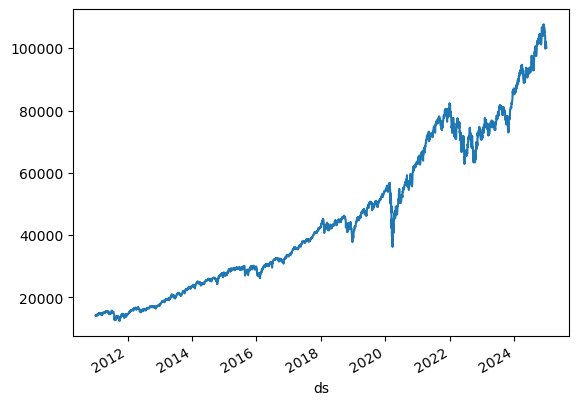

In [51]:
source.sum(axis=1).plot()

total sum if we consider a portfolio with one share per ticker then we get around $100,000 by 2024. We need to set initial_capital to a higher value, 1,000,000 in this case.

### Experiment 1: Wide dataset (stocks + ETFs)

In [52]:
parameters = {
    "population_size": 100,
    "num_generations": 100,
    "mutation_rate": 0.1,
    "elitism": 0.1,
    "n_periods": 10,
    "days_to_avg": 30,
    "days_to_opt": 30,
    "initial_capital": 1_000_000,
}

In [53]:
source_path_extended = '../../data/etfs_close.pkl'

In [54]:
source_extended = pd.read_pickle(source_path_extended)
source_extended.head()

Ticker,ds,AADR,ACWI,ACWX,AFG,AGG,AMLP,BIL,BIV,BND,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
0,2011-01-03,26.494179,35.018154,30.182961,14.173727,71.489235,26.573900,76.281036,50.488926,53.083935,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
1,2011-01-04,26.450108,34.981026,30.019852,14.104879,71.509521,26.491484,76.281036,50.562424,53.090553,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2,2011-01-05,26.291458,34.981026,29.992662,14.066156,71.164383,26.458506,76.281036,50.188774,52.858776,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
3,2011-01-06,26.291458,34.758274,29.727602,14.264087,71.177925,26.458506,76.281036,50.378658,52.905167,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
4,2011-01-07,26.150438,34.632030,29.578085,14.195246,71.408035,26.491484,76.264374,50.678814,53.103794,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


In [55]:
source_wide = pd.merge(source, source_extended, on='ds', how='left').set_index('ds').dropna()
print(source_wide.shape)
# Check if any row contains at least one NaN
#print(source_wide.isnull().any(axis=1))
# Check if any value in the DataFrame is null
has_any_nan = source_wide.isnull().values.any()
print("Any NaN in source_wide:", has_any_nan)
source_wide.head()

(3521, 680)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


In [56]:
df = source_wide.copy()
days_to_avg = parameters['days_to_avg']
display(df.head())
print(f'initial date: {df.iloc[days_to_avg+1, :].index}')

Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


initial date: Index(['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK',
       ...
       'XLP', 'XLU', 'XLV', 'XLY', 'XME', 'XOP', 'XPH', 'XRT', 'XSD', 'XTNT'],
      dtype='object', name='Ticker', length=680)


<Axes: xlabel='ds'>

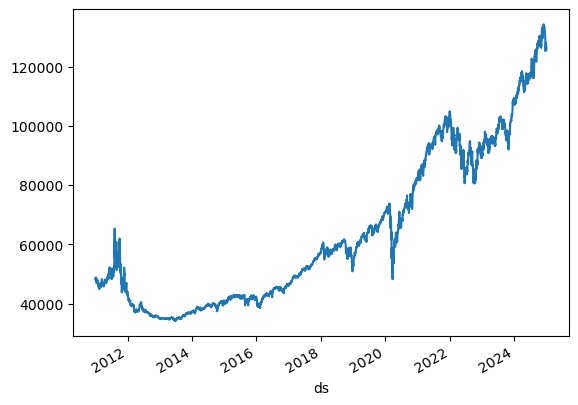

In [57]:
df.sum(axis=1).plot()

#### Equal Weights Baseline

In [58]:
opt_fun_ew = partial(equal_weights_baseline)

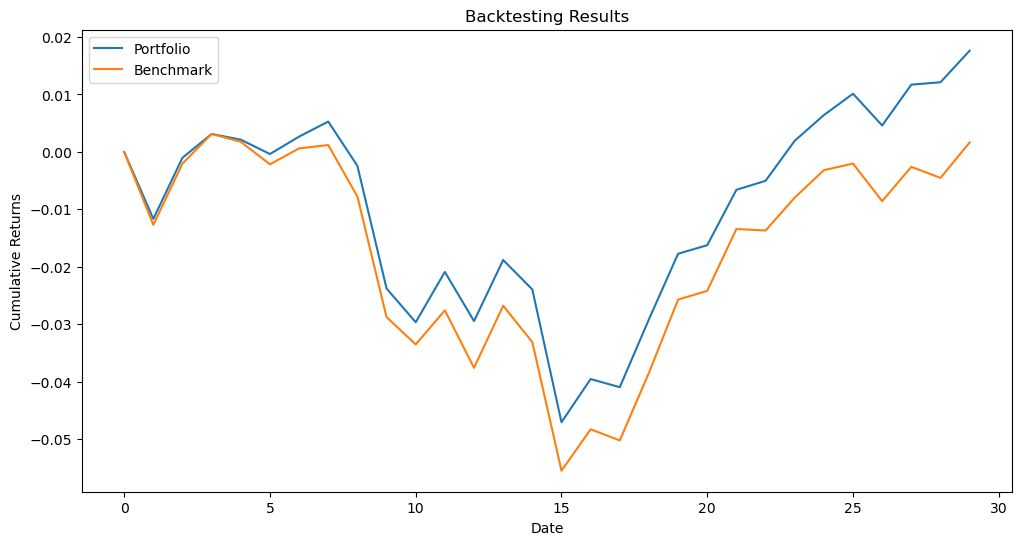

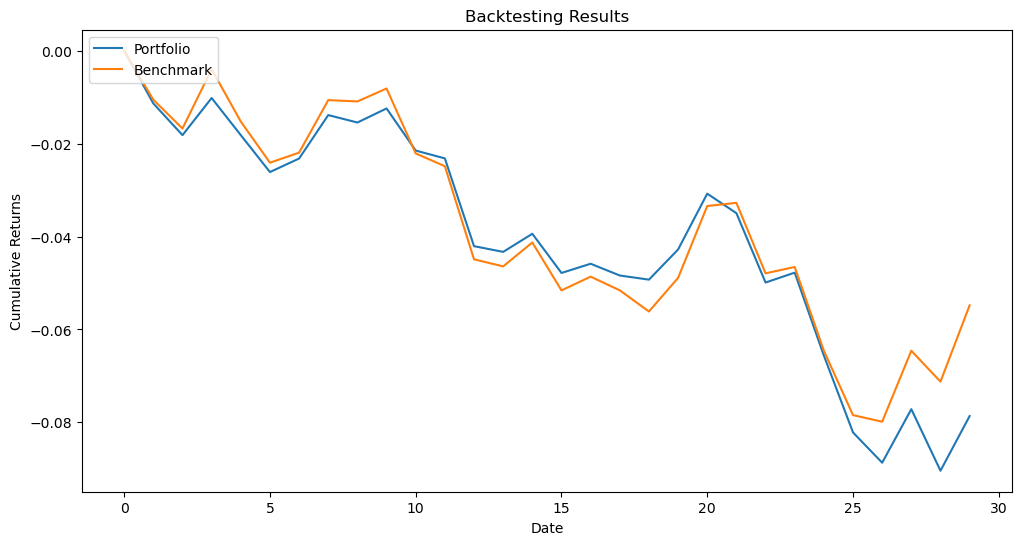

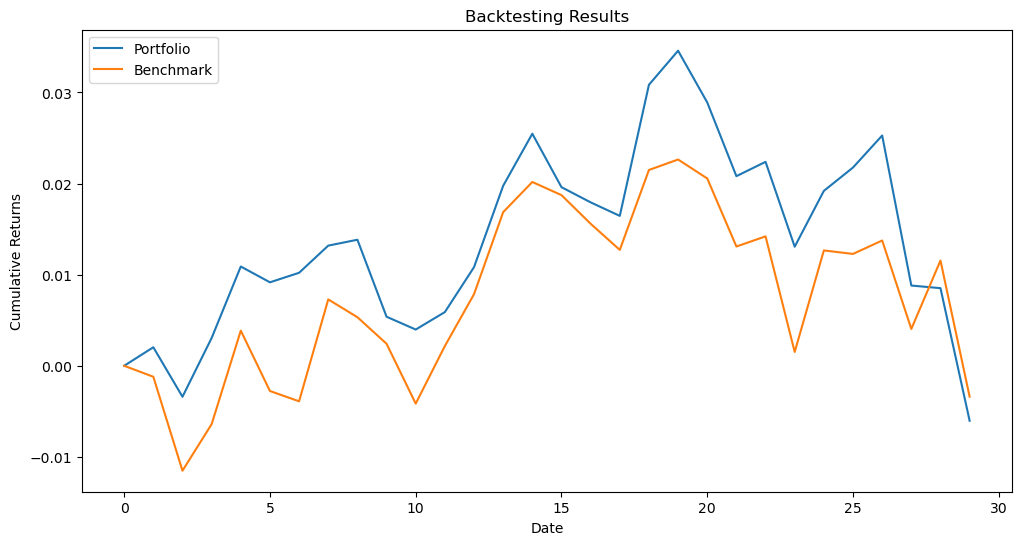

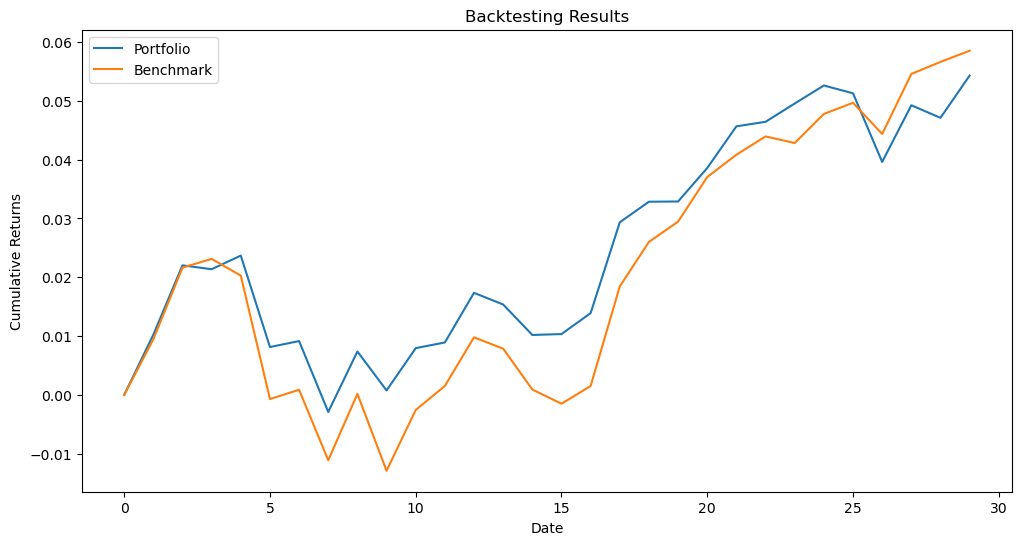

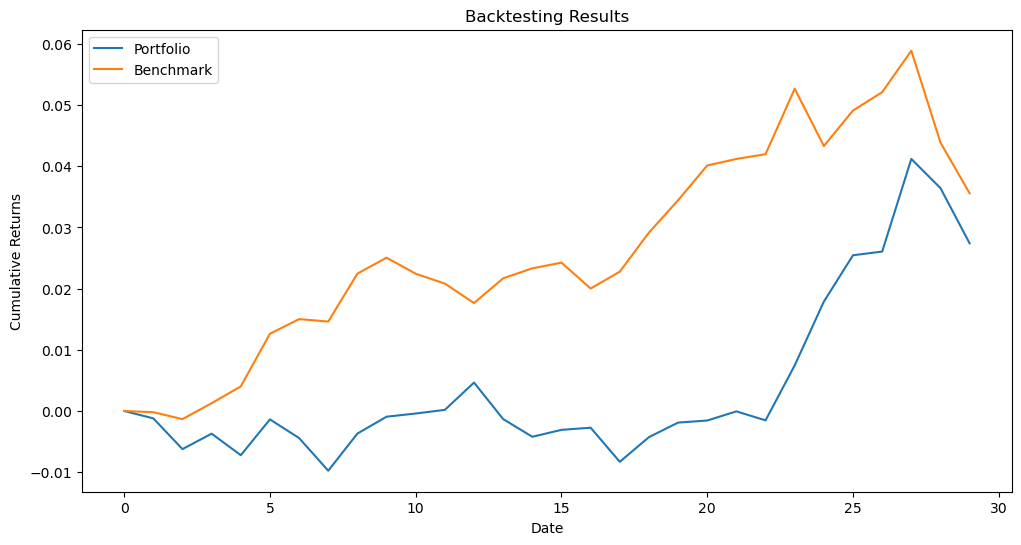

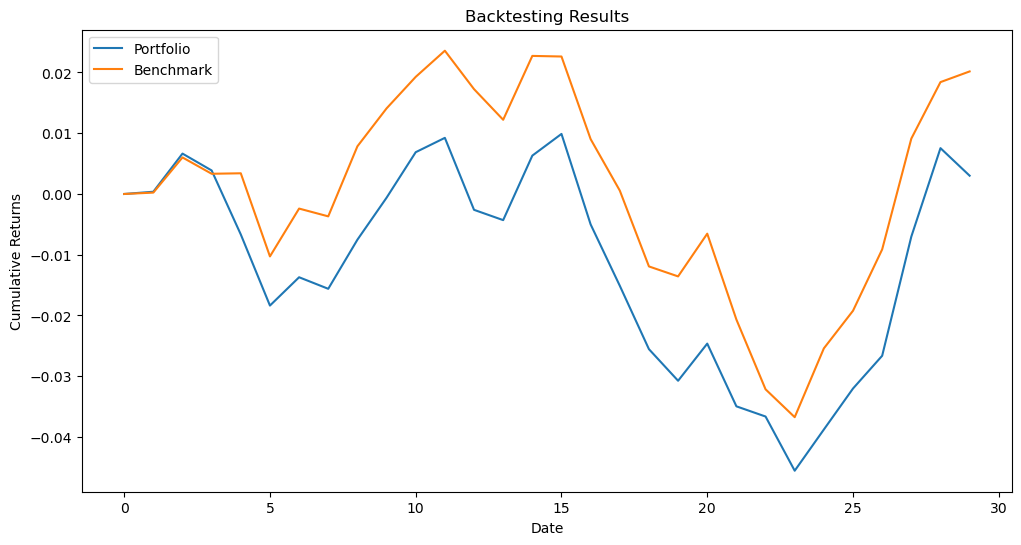

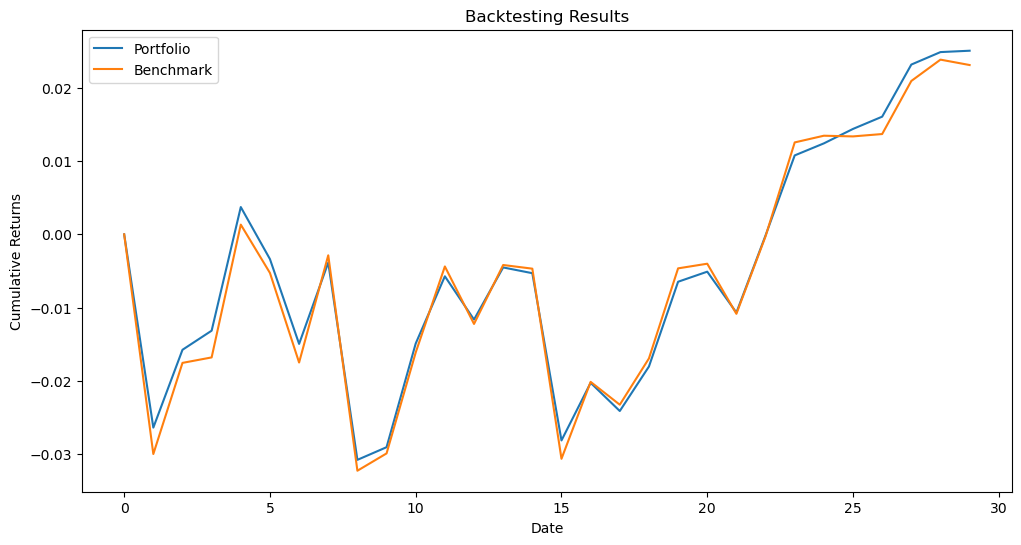

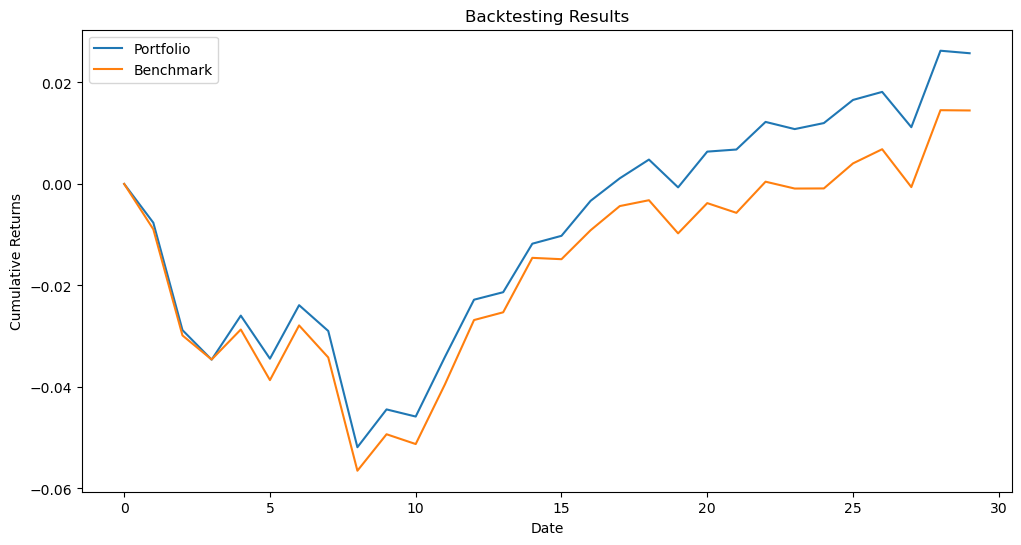

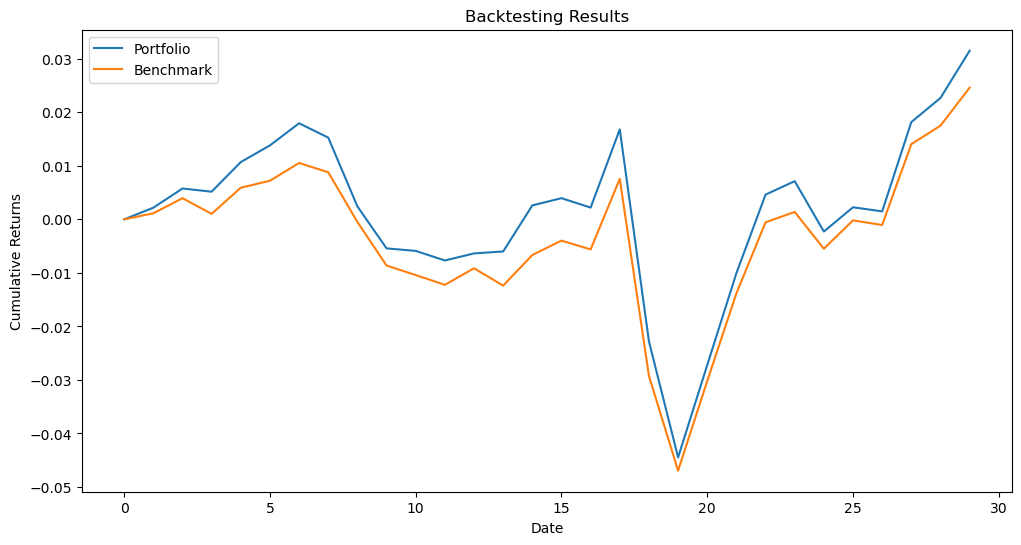

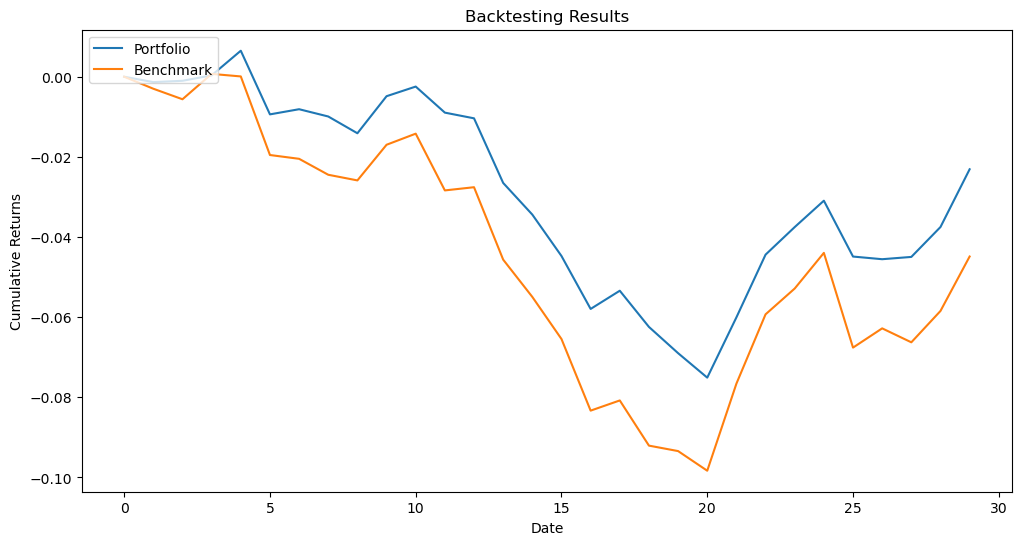

In [59]:
results_path_ew_wide = '../../results/sharpe_optimization/results_ew_{}.pkl'
_ = run_experiment(results_path_ew_wide, df, benchmark, opt_fun_ew, parameters)

#### GA

In [60]:
opt_fun_ga = partial(genetic_algorithm_sharpe, 
                  population_size=parameters["population_size"], 
                  num_generations=parameters["num_generations"], 
                  mutation_rate=parameters["mutation_rate"], 
                  elitism=parameters["elitism"])

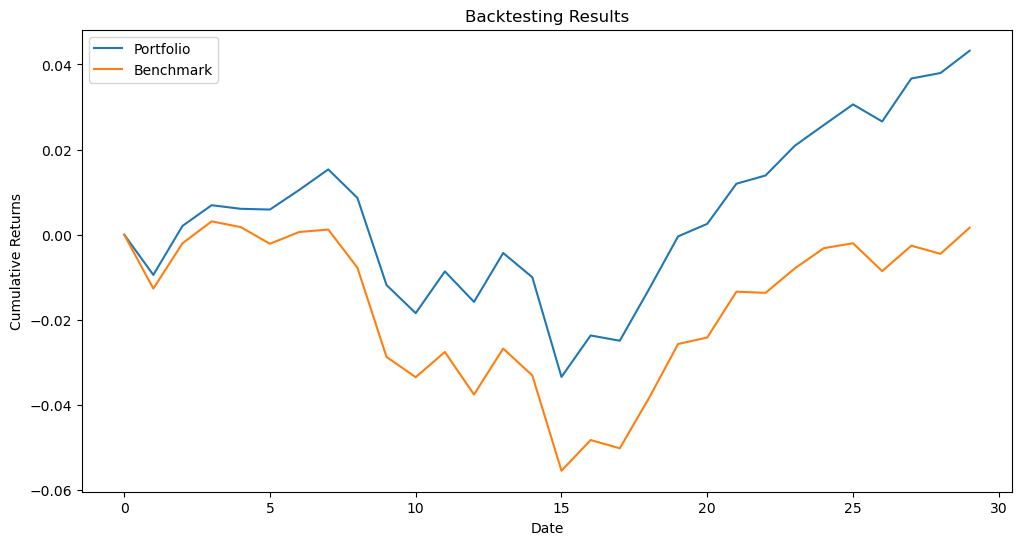

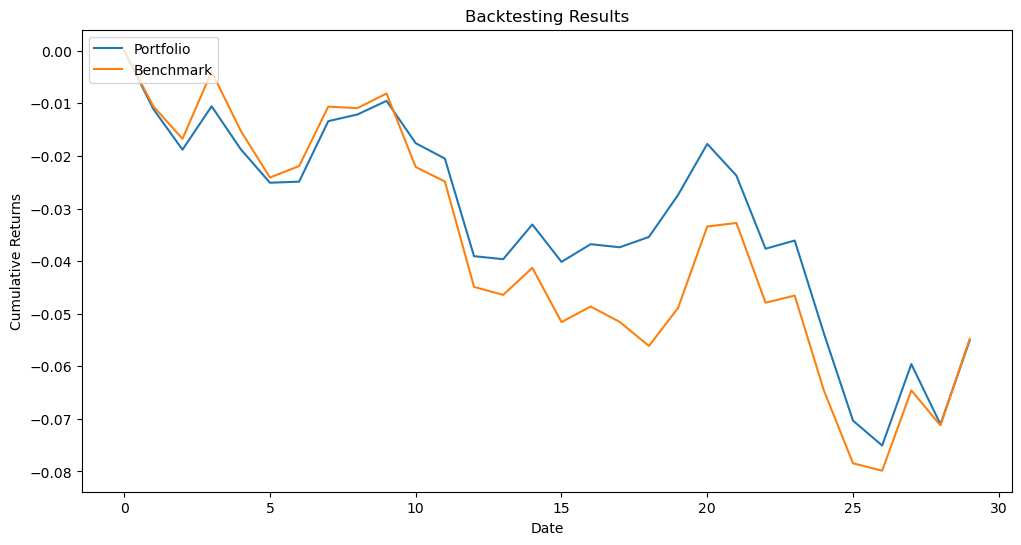

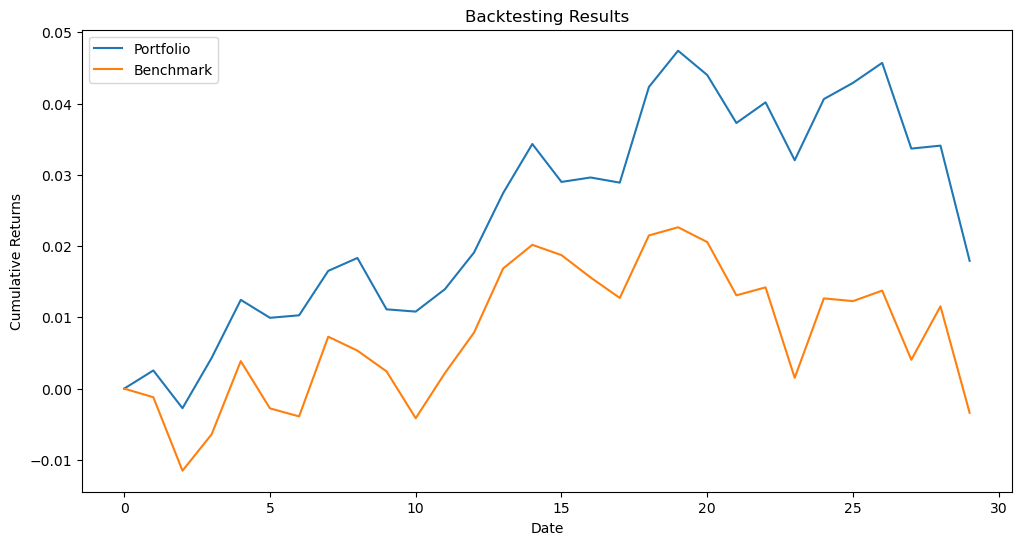

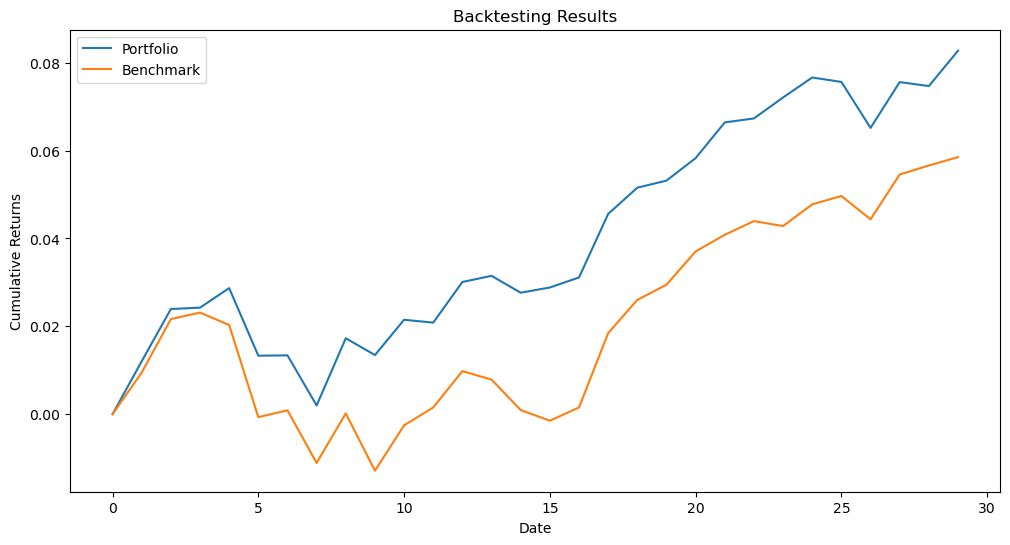

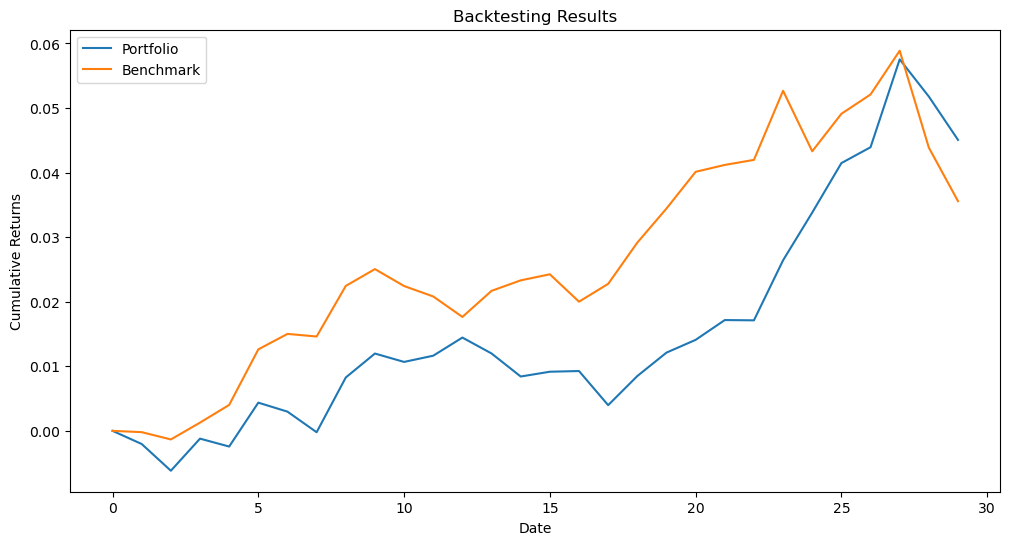

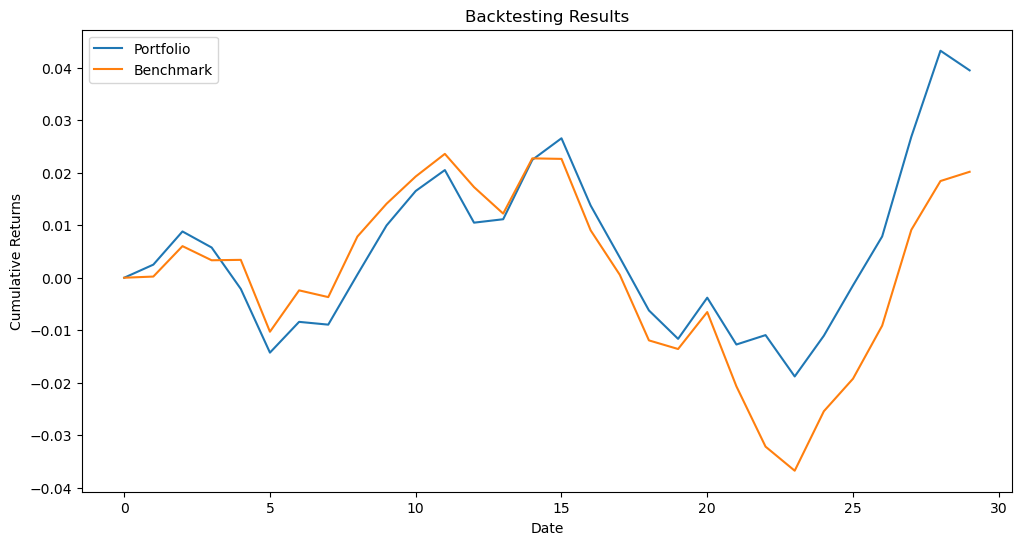

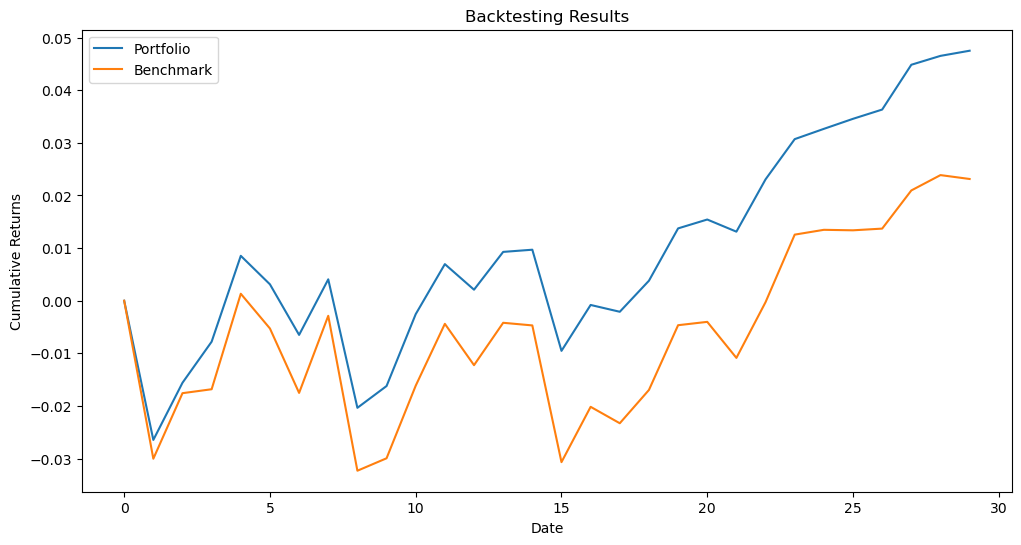

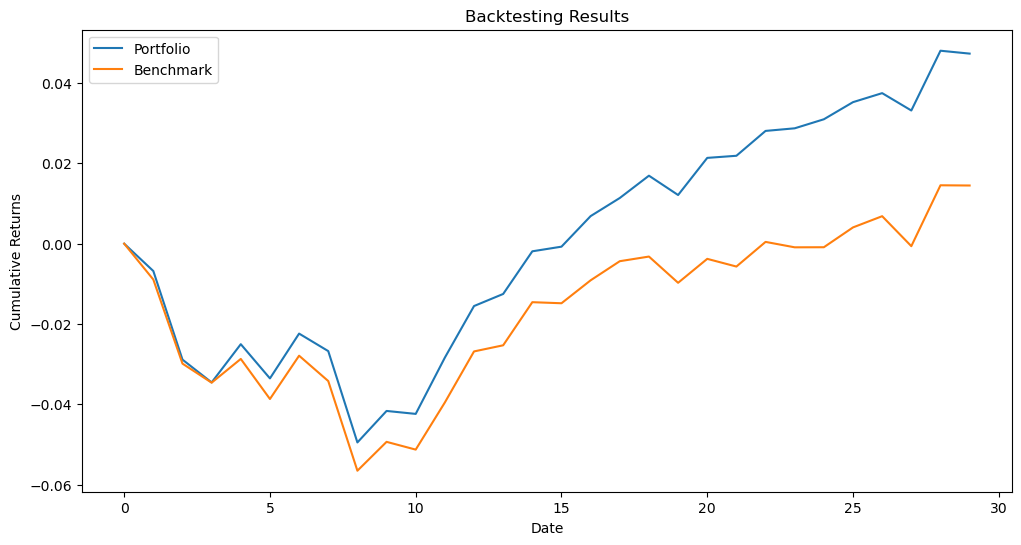

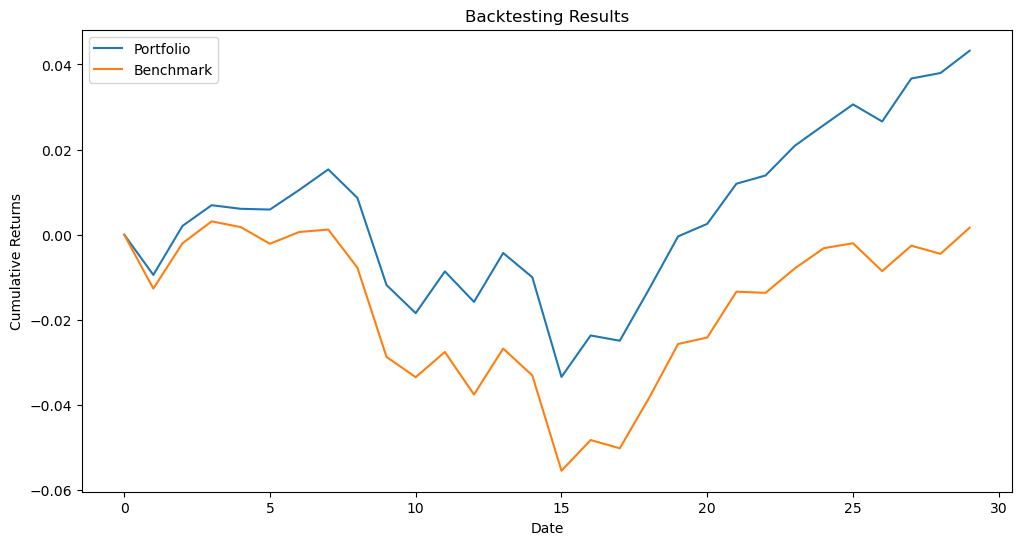

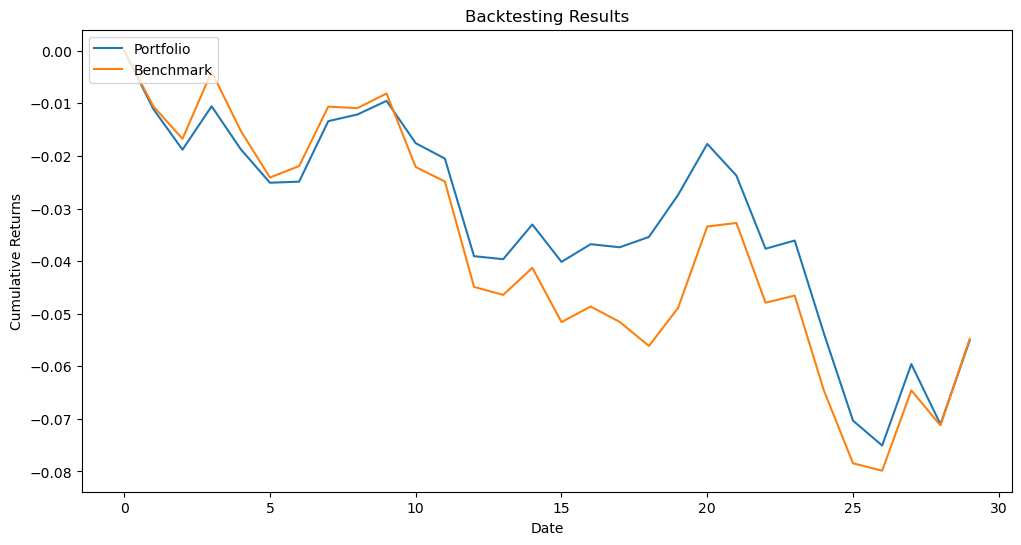

In [61]:
results_path_ga_wide = '../../results/sharpe_optimization/results_ga_{}.pkl'
_ = run_experiment(results_path_ga_wide, df, benchmark, opt_fun_ga, parameters)

#### BF

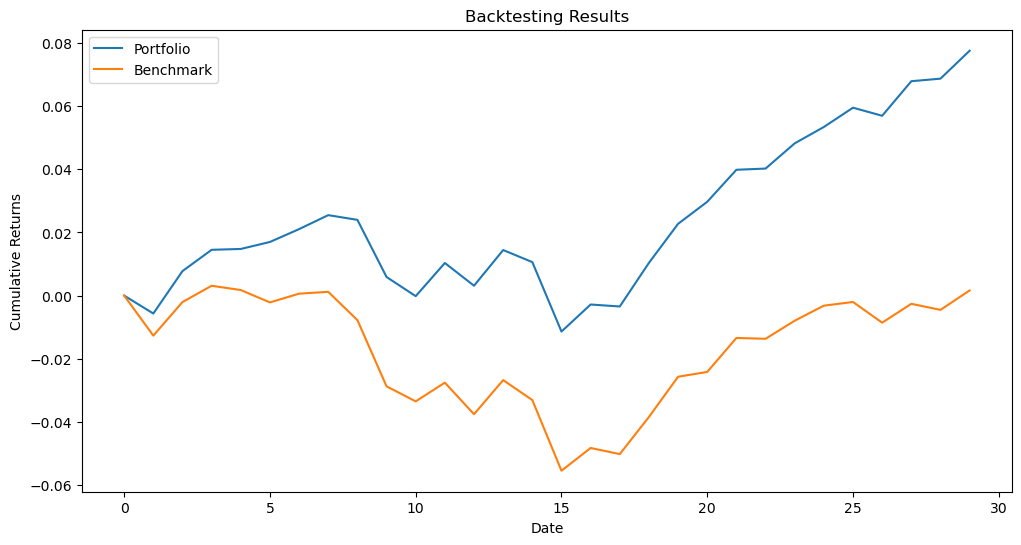

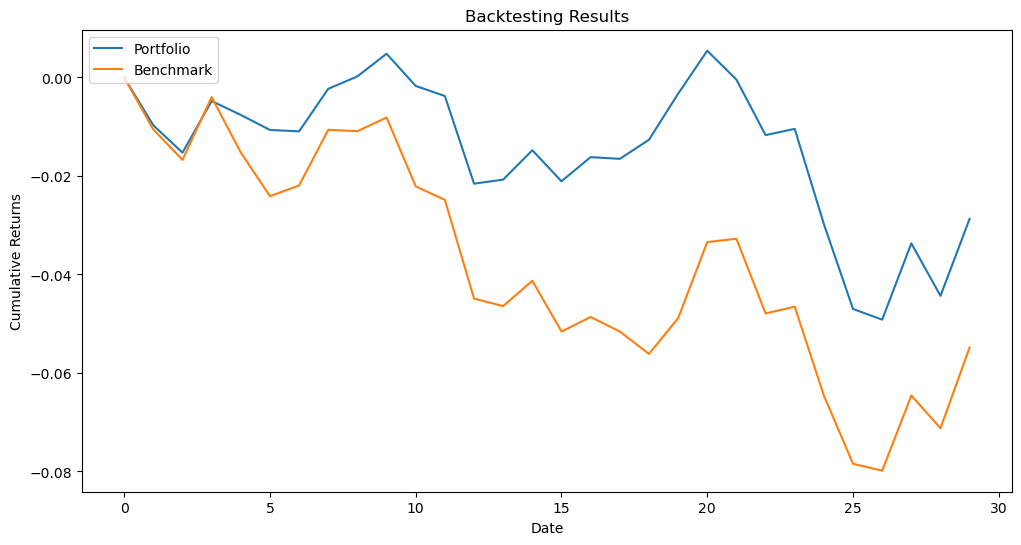

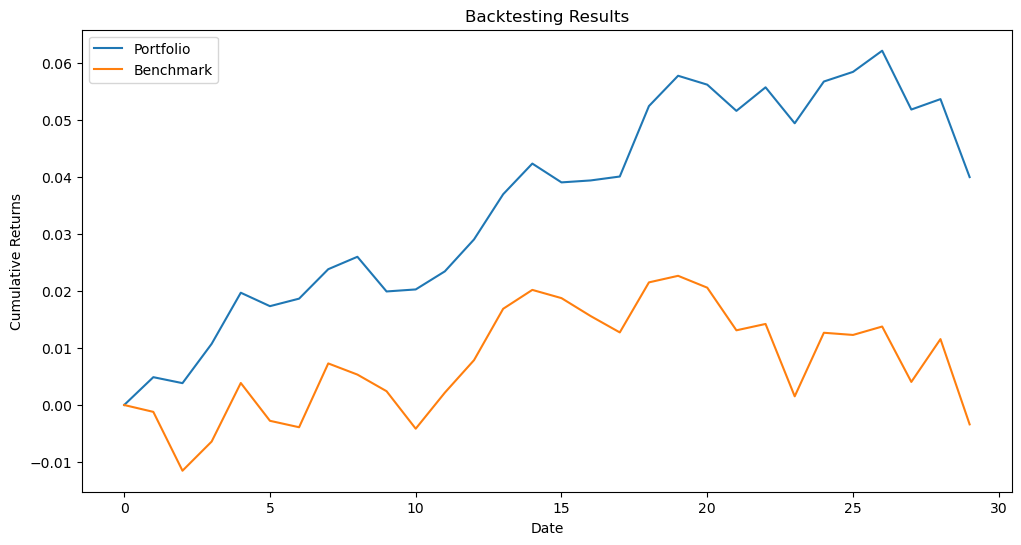

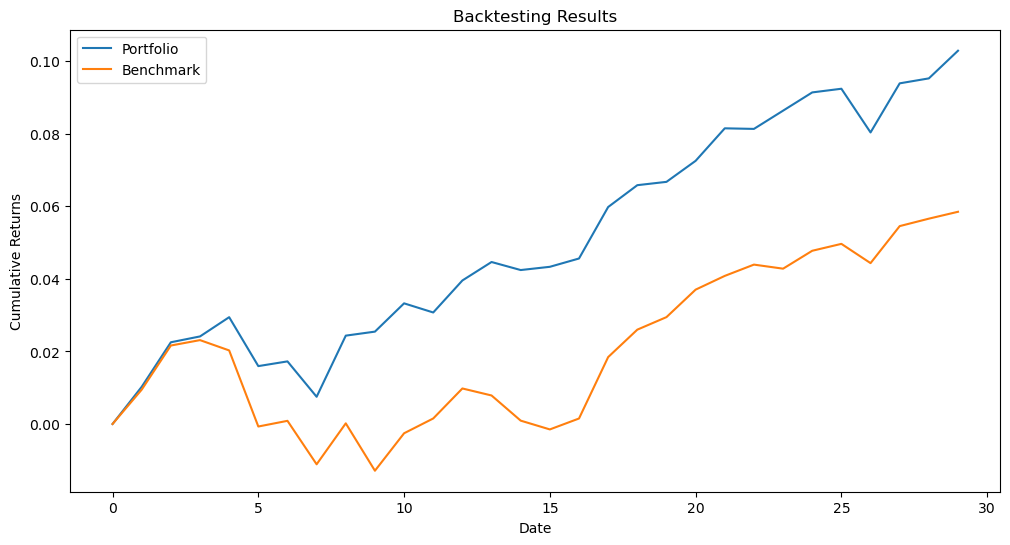

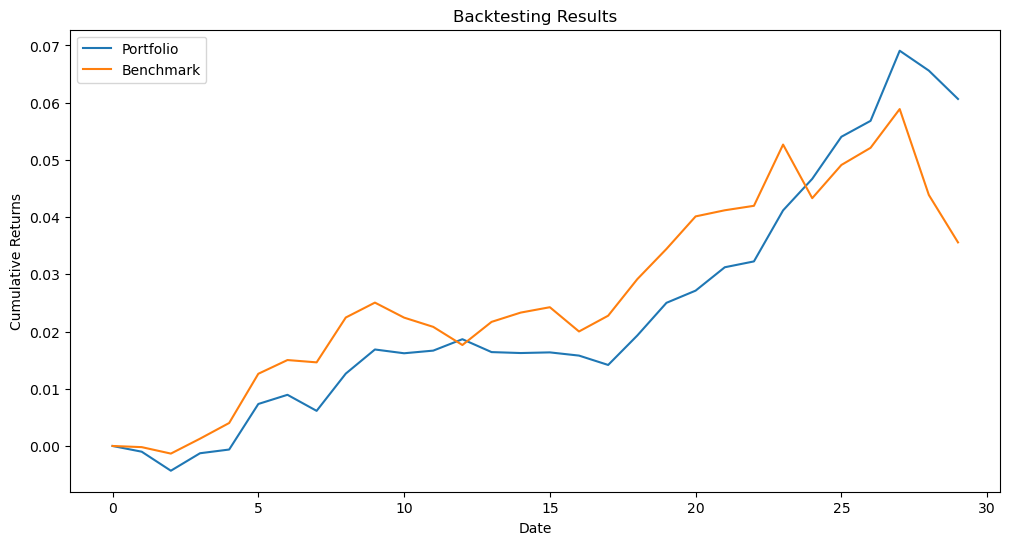

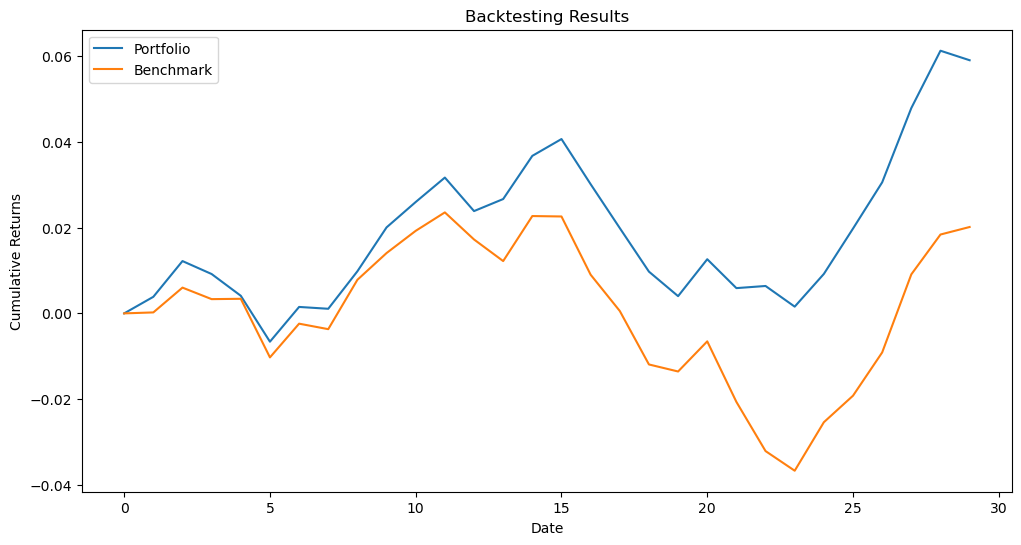

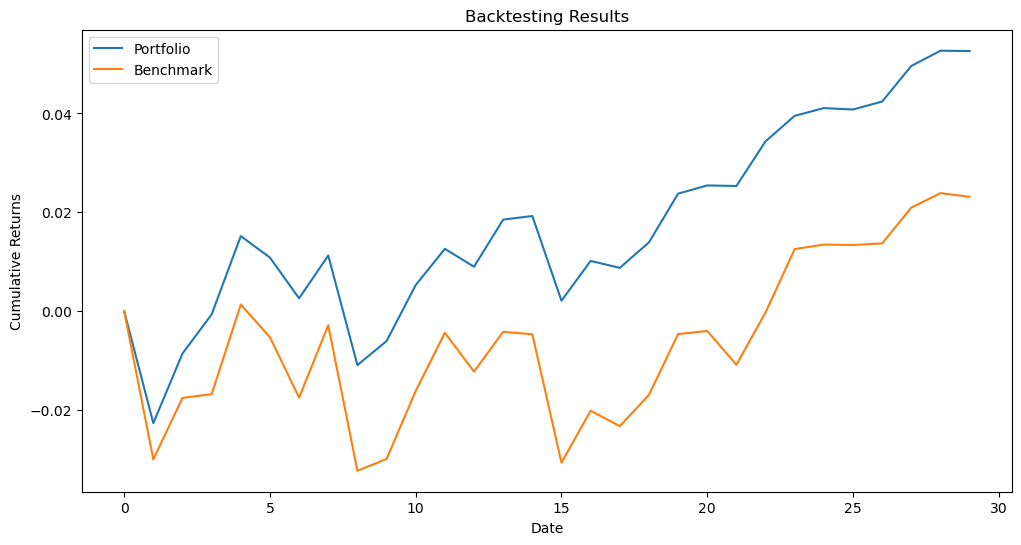

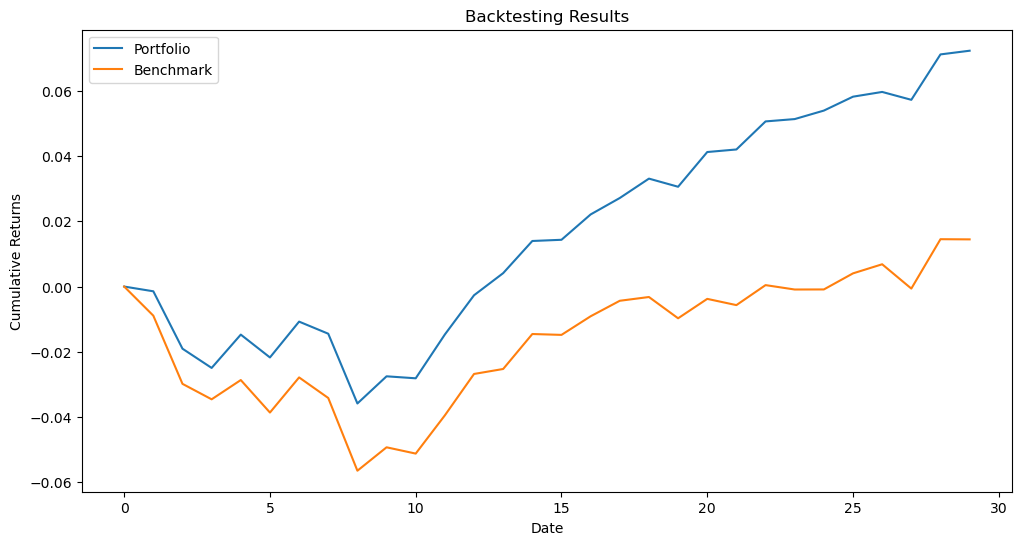

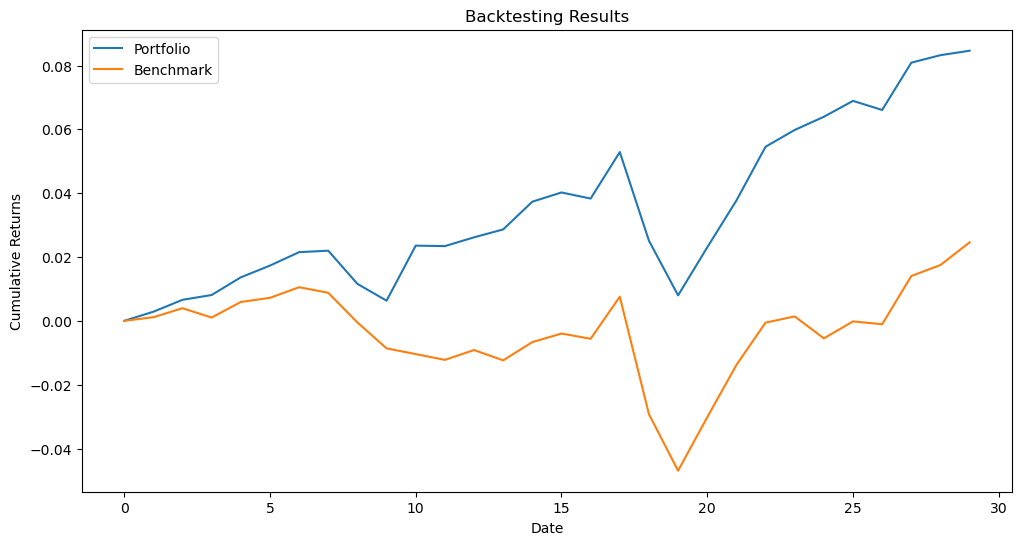

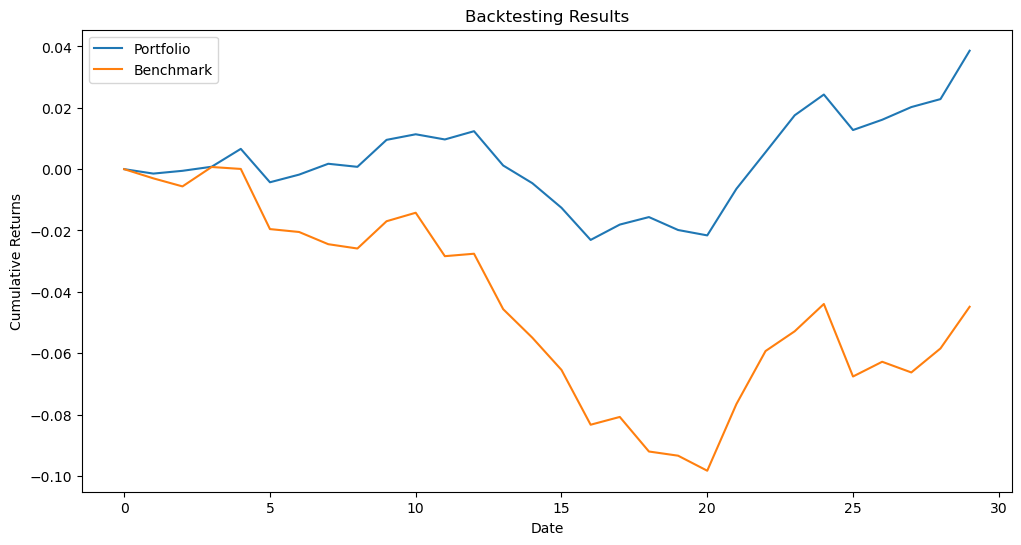

In [62]:
opt_fun_bf = partial(scipy_minimize_sharpe)
results_path_bf = '../../results/sharpe_optimization/results_bf_{}.pkl'
_ = run_experiment(results_path_bf, df, benchmark, opt_fun_bf, parameters)

#### HRP

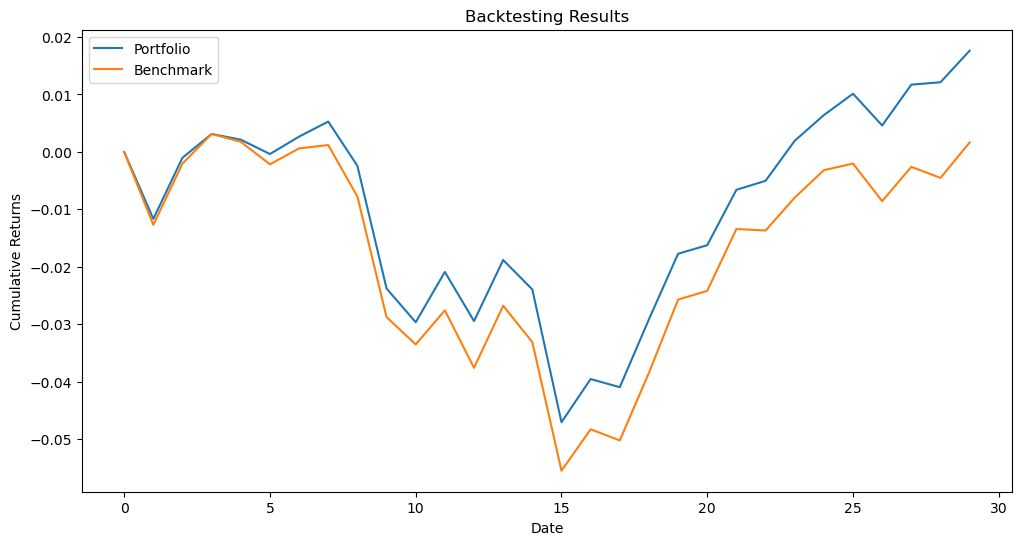

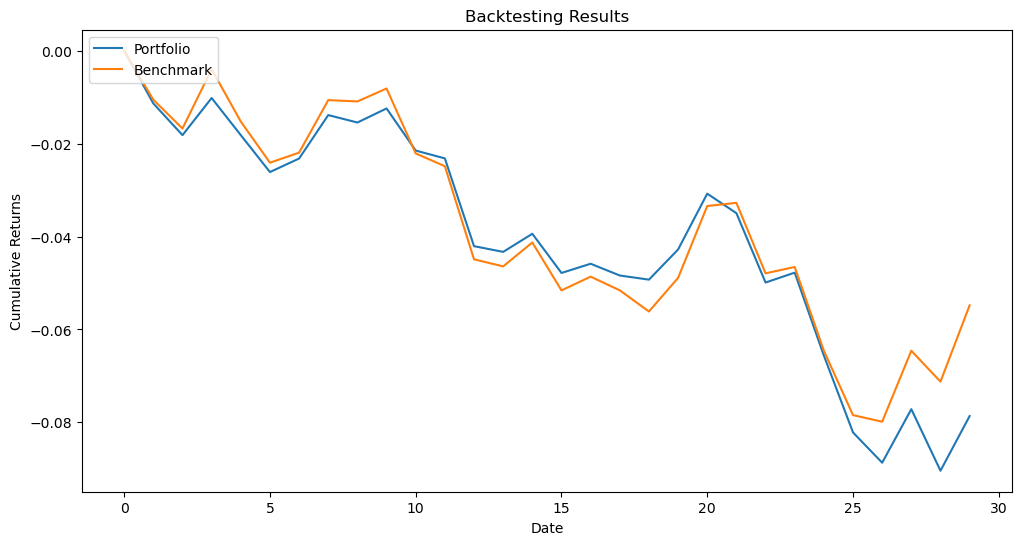

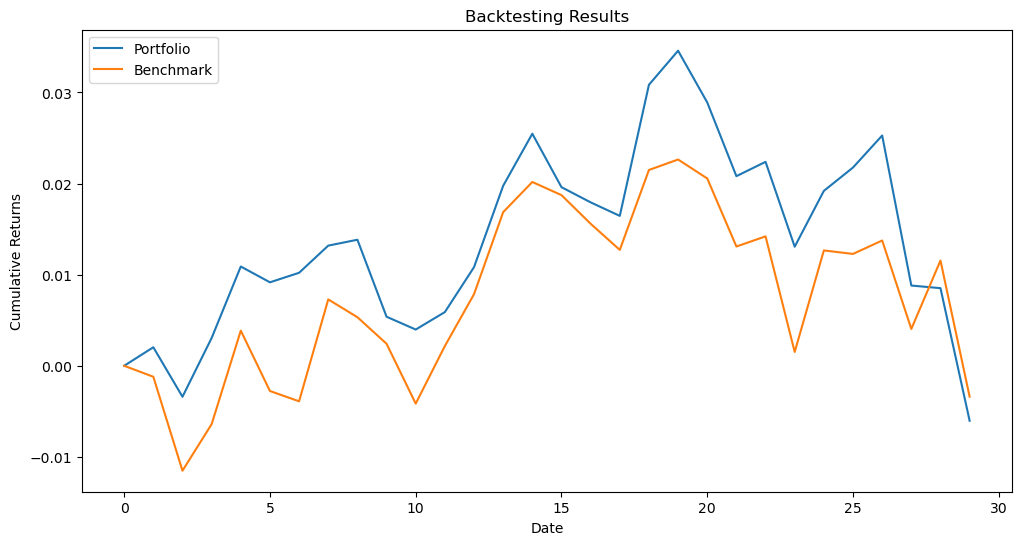

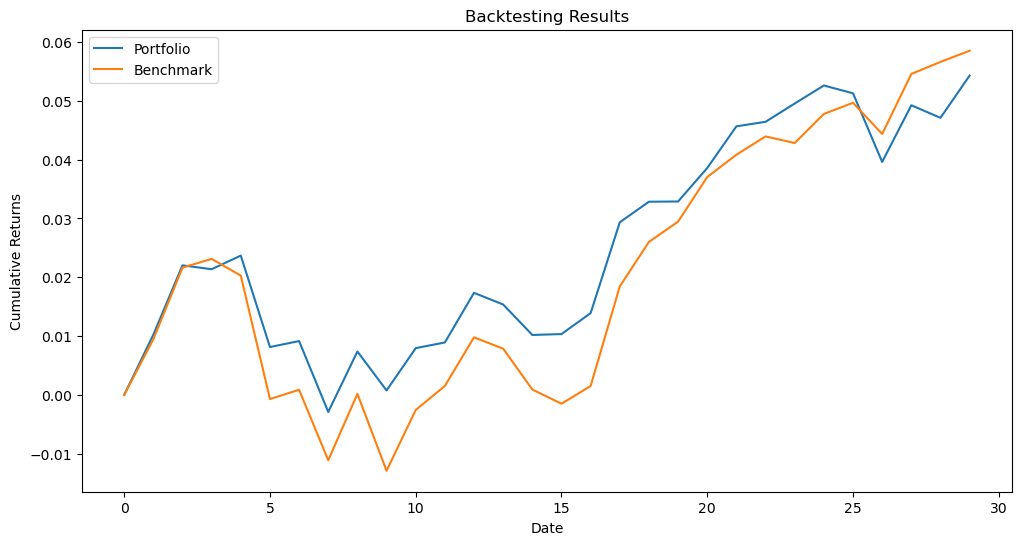

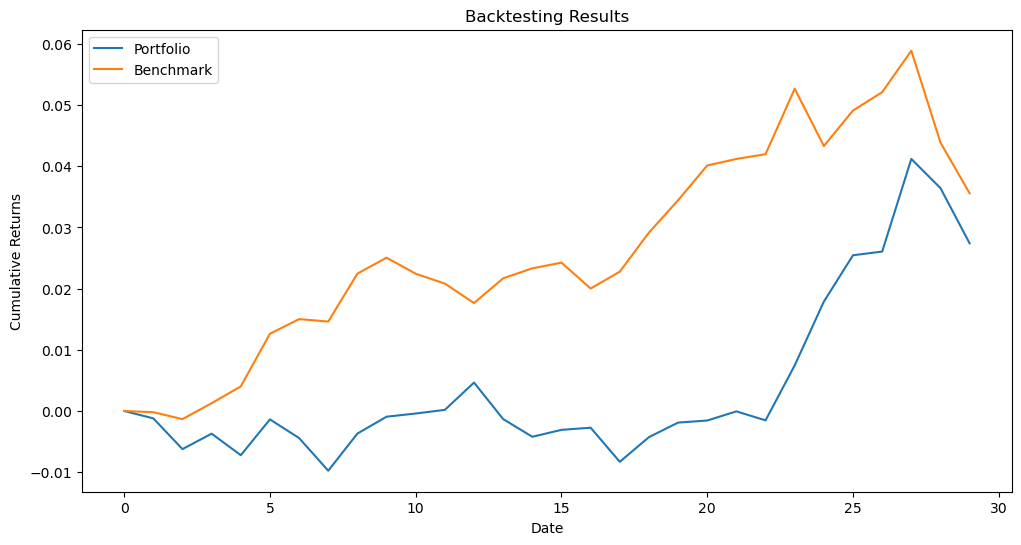

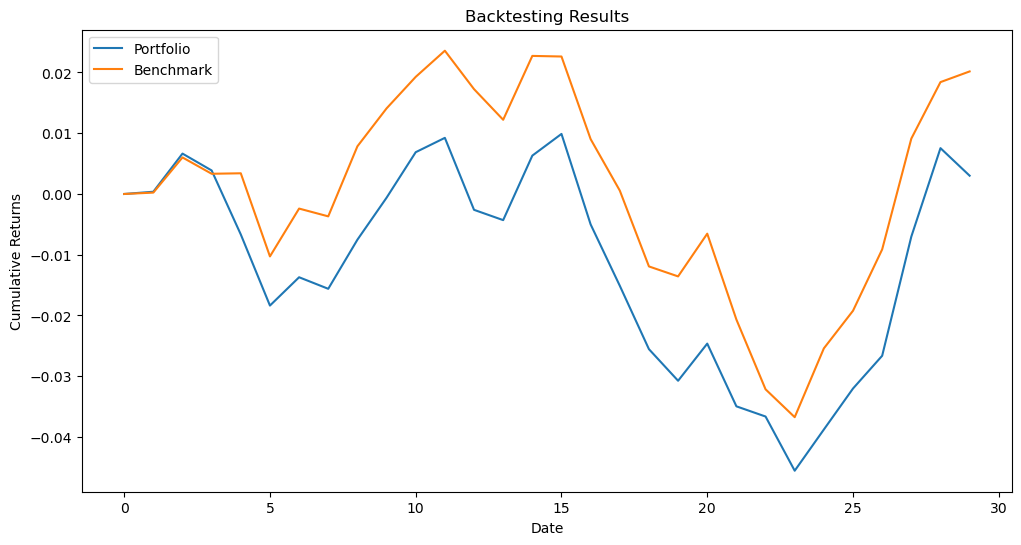

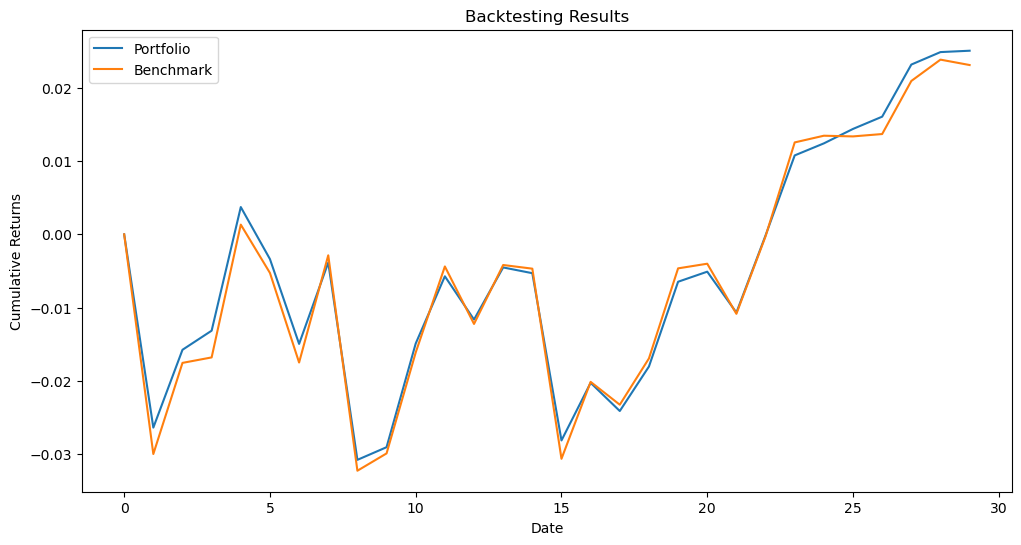

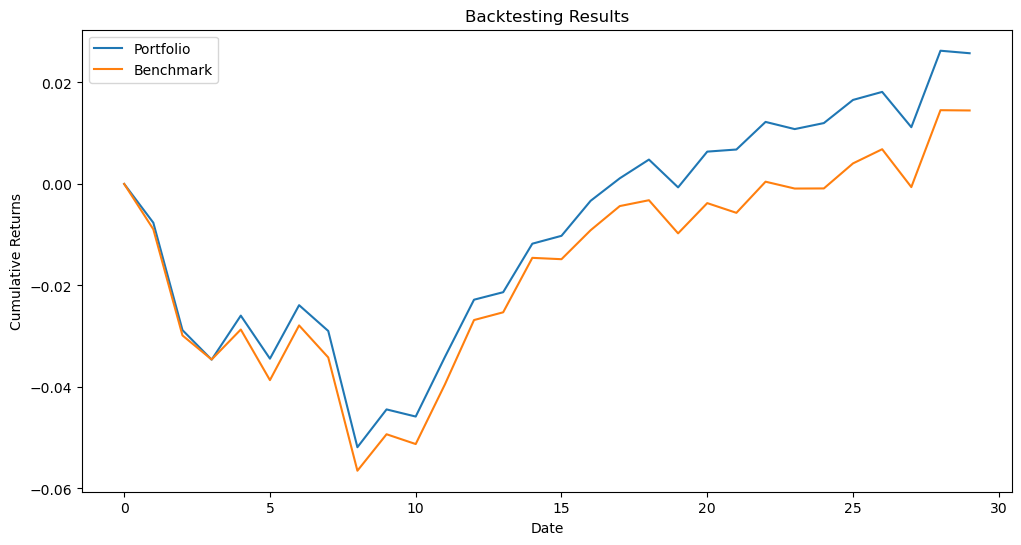

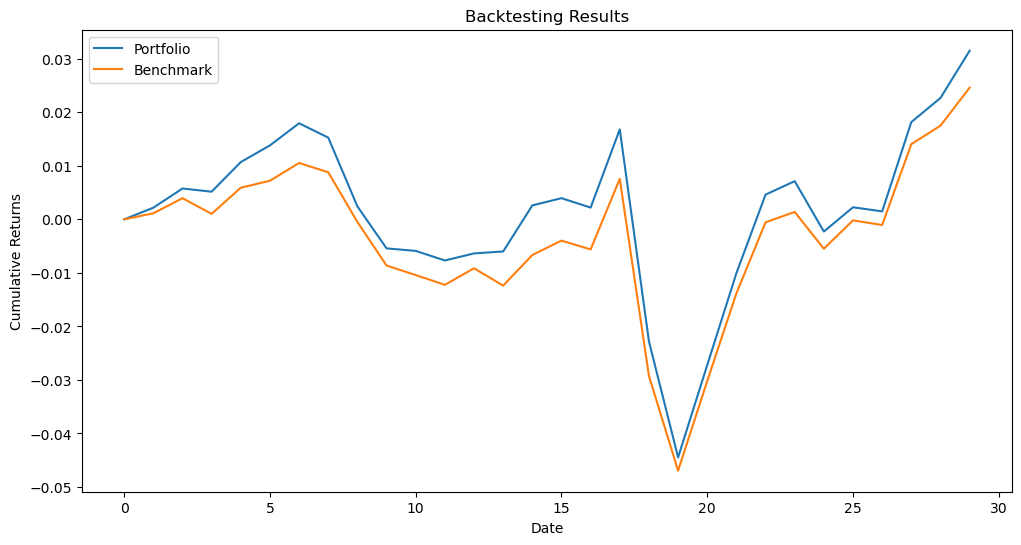

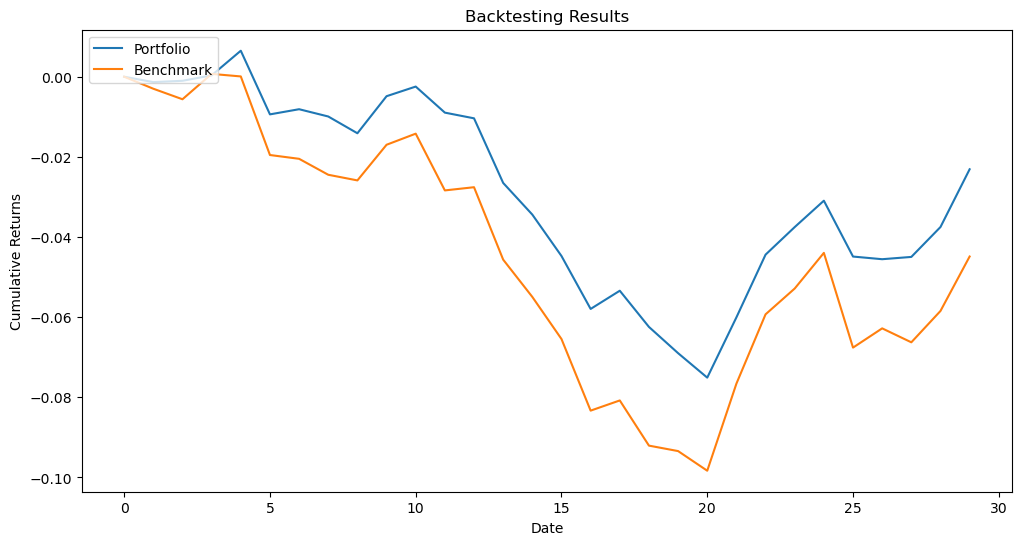

In [63]:
opt_fun_hrp = partial(riskfolio_sharpe_optimized)
results_path = '../../results/sharpe_optimization/results_hrp_{}.pkl'
_ = run_experiment(results_path, df, benchmark, opt_fun_hrp, parameters)

#### Method comparison 

2025-10-16 08:17:34,882 - inspect_results_logger - INFO - Period 0: Loaded Equal Weights (exec_time: 0.10s)
2025-10-16 08:17:34,882 - inspect_results_logger - INFO - Period 0: Loaded Equal Weights (exec_time: 0.10s)
2025-10-16 08:17:34,885 - inspect_results_logger - INFO - Period 0: Loaded Genetic Algorithm (exec_time: 4359.36s)
2025-10-16 08:17:34,885 - inspect_results_logger - INFO - Period 0: Loaded Genetic Algorithm (exec_time: 4359.36s)
2025-10-16 08:17:34,887 - inspect_results_logger - INFO - Period 0: Loaded Scipy SLSQP (exec_time: 2299.47s)
2025-10-16 08:17:34,887 - inspect_results_logger - INFO - Period 0: Loaded Scipy SLSQP (exec_time: 2299.47s)
2025-10-16 08:17:34,889 - inspect_results_logger - INFO - Period 0: Loaded Hierarchical Risk Parity (exec_time: 10.56s)
2025-10-16 08:17:34,889 - inspect_results_logger - INFO - Period 0: Loaded Hierarchical Risk Parity (exec_time: 10.56s)


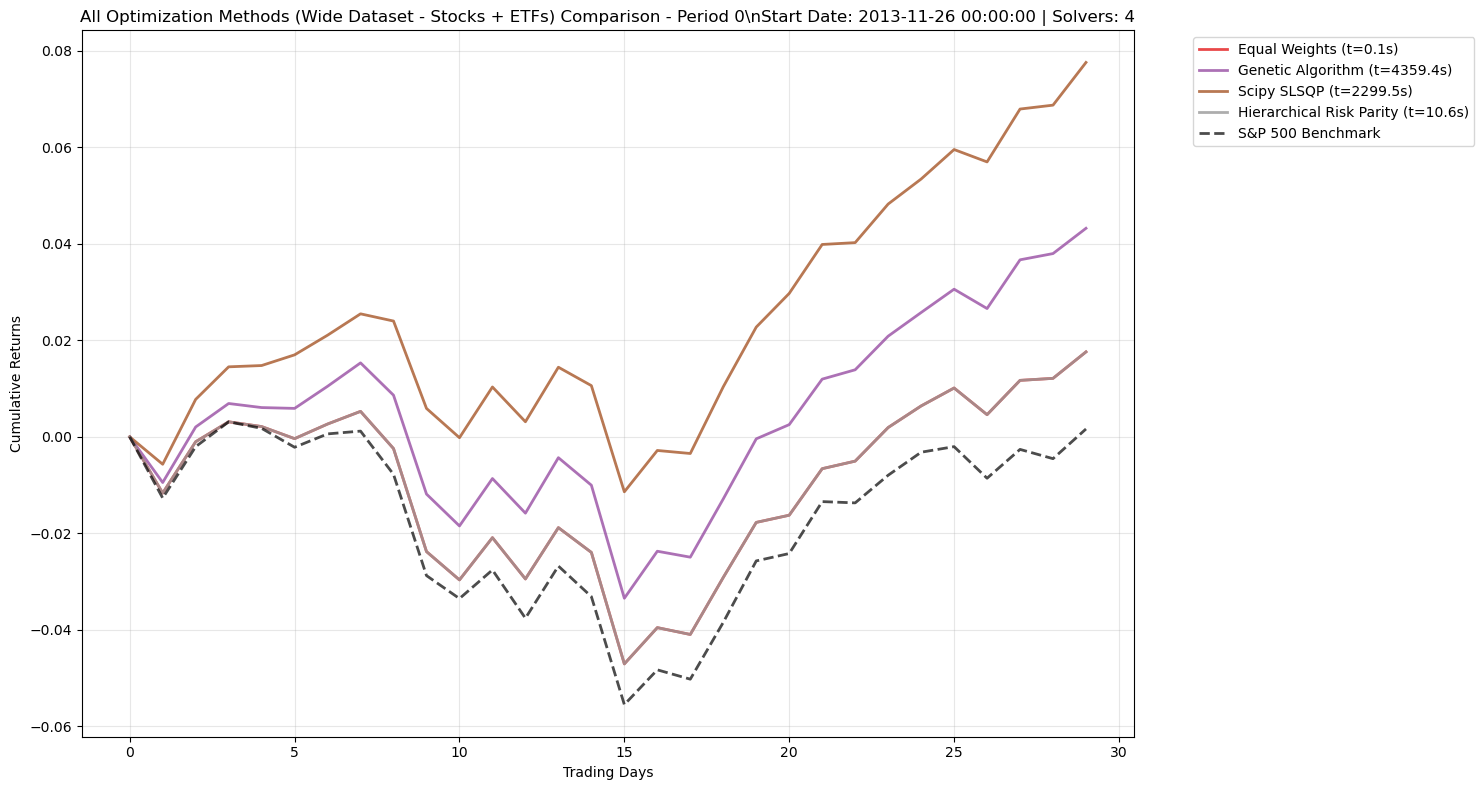

2025-10-16 08:17:34,978 - inspect_results_logger - INFO - Period 1: Loaded Equal Weights (exec_time: 0.10s)
2025-10-16 08:17:34,978 - inspect_results_logger - INFO - Period 1: Loaded Equal Weights (exec_time: 0.10s)
2025-10-16 08:17:34,981 - inspect_results_logger - INFO - Period 1: Loaded Genetic Algorithm (exec_time: 4357.10s)
2025-10-16 08:17:34,981 - inspect_results_logger - INFO - Period 1: Loaded Genetic Algorithm (exec_time: 4357.10s)
2025-10-16 08:17:34,983 - inspect_results_logger - INFO - Period 1: Loaded Scipy SLSQP (exec_time: 2042.80s)
2025-10-16 08:17:34,983 - inspect_results_logger - INFO - Period 1: Loaded Scipy SLSQP (exec_time: 2042.80s)
2025-10-16 08:17:34,985 - inspect_results_logger - INFO - Period 1: Loaded Hierarchical Risk Parity (exec_time: 11.23s)
2025-10-16 08:17:34,985 - inspect_results_logger - INFO - Period 1: Loaded Hierarchical Risk Parity (exec_time: 11.23s)


\nPeriod 0 Summary:
--------------------------------------------------
Equal Weights            :   0.0176 (  0.10s)
Genetic Algorithm        :   0.0432 (4359.36s)
Scipy SLSQP              :   0.0776 (2299.47s)
Hierarchical Risk Parity :   0.0176 ( 10.56s)
Benchmark                :   0.0016



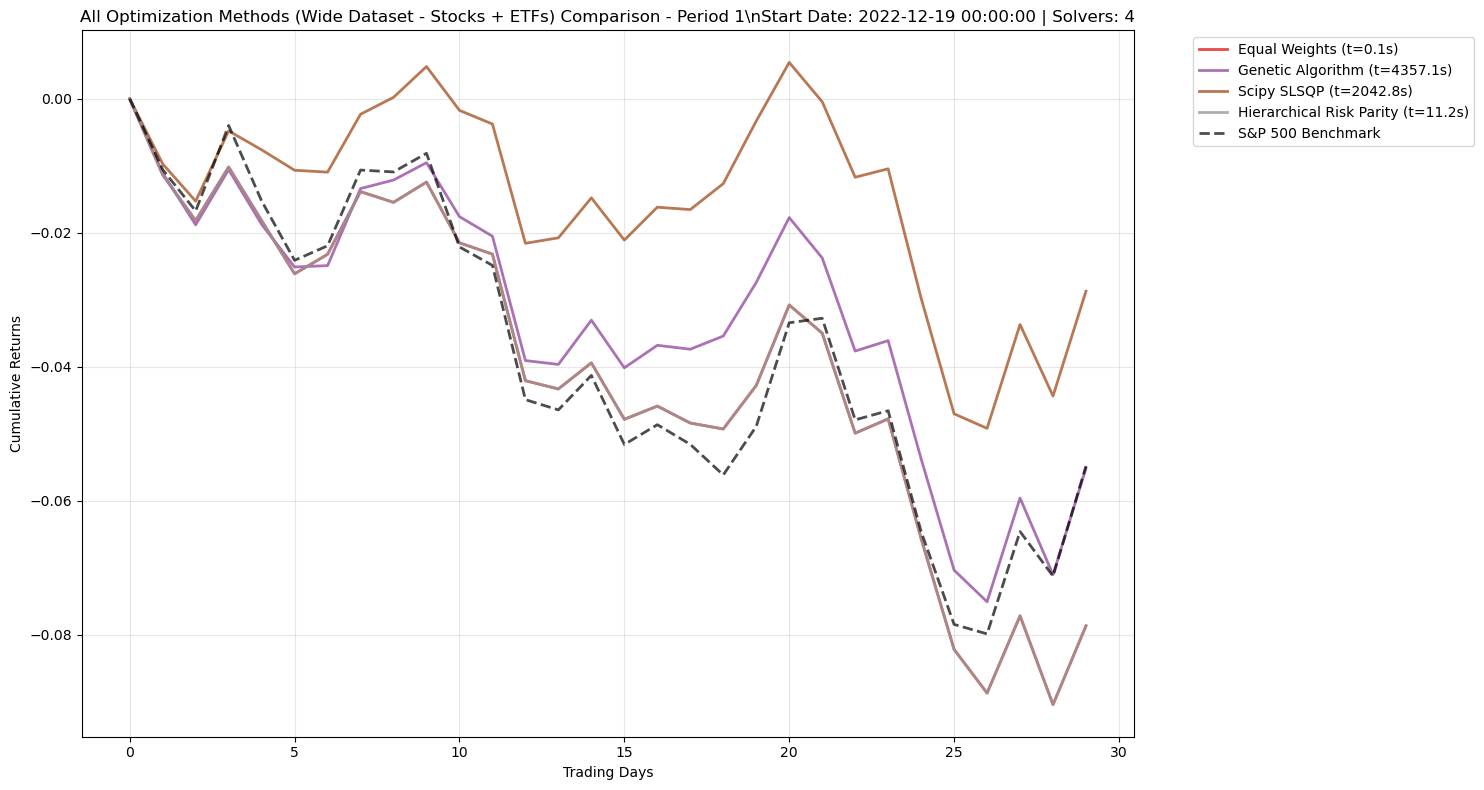

2025-10-16 08:17:35,069 - inspect_results_logger - INFO - Period 2: Loaded Equal Weights (exec_time: 0.10s)
2025-10-16 08:17:35,069 - inspect_results_logger - INFO - Period 2: Loaded Equal Weights (exec_time: 0.10s)
2025-10-16 08:17:35,071 - inspect_results_logger - INFO - Period 2: Loaded Genetic Algorithm (exec_time: 4360.89s)
2025-10-16 08:17:35,071 - inspect_results_logger - INFO - Period 2: Loaded Genetic Algorithm (exec_time: 4360.89s)
2025-10-16 08:17:35,073 - inspect_results_logger - INFO - Period 2: Loaded Scipy SLSQP (exec_time: 3558.34s)
2025-10-16 08:17:35,073 - inspect_results_logger - INFO - Period 2: Loaded Scipy SLSQP (exec_time: 3558.34s)
2025-10-16 08:17:35,075 - inspect_results_logger - INFO - Period 2: Loaded Hierarchical Risk Parity (exec_time: 10.68s)
2025-10-16 08:17:35,075 - inspect_results_logger - INFO - Period 2: Loaded Hierarchical Risk Parity (exec_time: 10.68s)


\nPeriod 1 Summary:
--------------------------------------------------
Equal Weights            :  -0.0786 (  0.10s)
Genetic Algorithm        :  -0.0551 (4357.10s)
Scipy SLSQP              :  -0.0287 (2042.80s)
Hierarchical Risk Parity :  -0.0786 ( 11.23s)
Benchmark                :  -0.0548



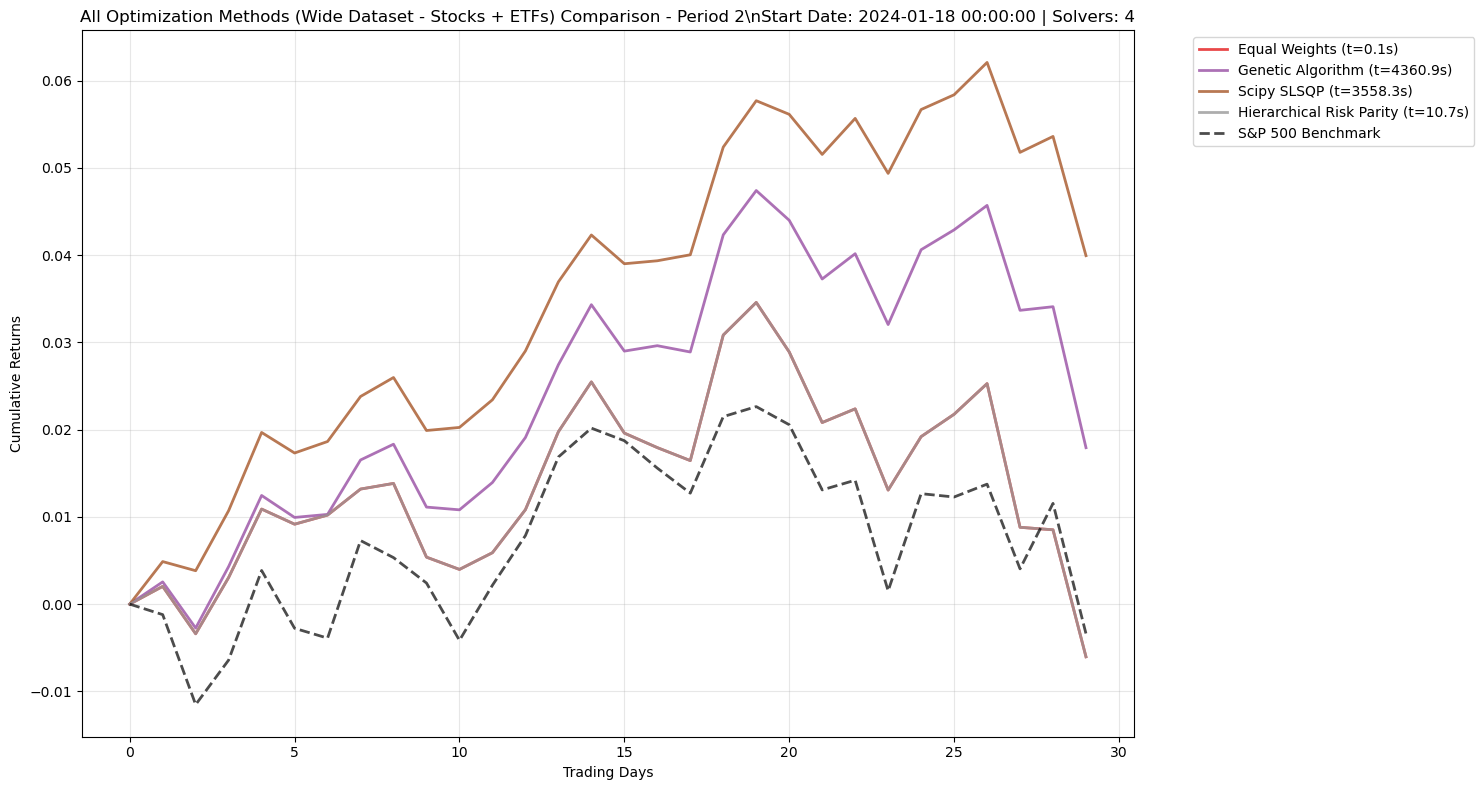

2025-10-16 08:17:35,165 - inspect_results_logger - INFO - Period 3: Loaded Equal Weights (exec_time: 0.10s)
2025-10-16 08:17:35,165 - inspect_results_logger - INFO - Period 3: Loaded Equal Weights (exec_time: 0.10s)
2025-10-16 08:17:35,167 - inspect_results_logger - INFO - Period 3: Loaded Genetic Algorithm (exec_time: 4357.56s)
2025-10-16 08:17:35,167 - inspect_results_logger - INFO - Period 3: Loaded Genetic Algorithm (exec_time: 4357.56s)
2025-10-16 08:17:35,169 - inspect_results_logger - INFO - Period 3: Loaded Scipy SLSQP (exec_time: 1953.00s)
2025-10-16 08:17:35,169 - inspect_results_logger - INFO - Period 3: Loaded Scipy SLSQP (exec_time: 1953.00s)
2025-10-16 08:17:35,171 - inspect_results_logger - INFO - Period 3: Loaded Hierarchical Risk Parity (exec_time: 11.03s)
2025-10-16 08:17:35,171 - inspect_results_logger - INFO - Period 3: Loaded Hierarchical Risk Parity (exec_time: 11.03s)


\nPeriod 2 Summary:
--------------------------------------------------
Equal Weights            :  -0.0060 (  0.10s)
Genetic Algorithm        :   0.0179 (4360.89s)
Scipy SLSQP              :   0.0399 (3558.34s)
Hierarchical Risk Parity :  -0.0060 ( 10.68s)
Benchmark                :  -0.0034



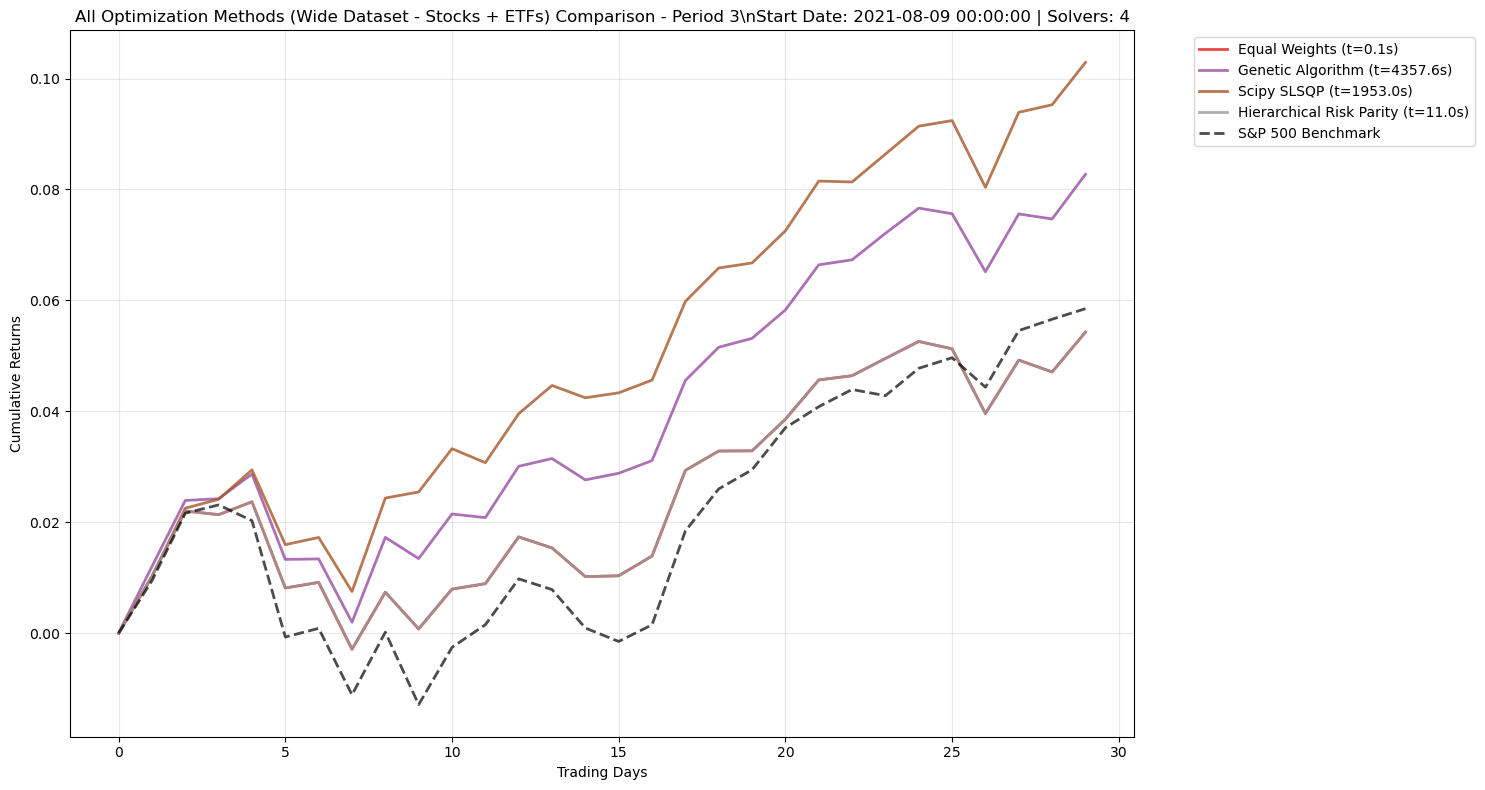

2025-10-16 08:17:35,258 - inspect_results_logger - INFO - Period 4: Loaded Equal Weights (exec_time: 0.10s)
2025-10-16 08:17:35,258 - inspect_results_logger - INFO - Period 4: Loaded Equal Weights (exec_time: 0.10s)
2025-10-16 08:17:35,260 - inspect_results_logger - INFO - Period 4: Loaded Genetic Algorithm (exec_time: 4344.37s)
2025-10-16 08:17:35,260 - inspect_results_logger - INFO - Period 4: Loaded Genetic Algorithm (exec_time: 4344.37s)
2025-10-16 08:17:35,262 - inspect_results_logger - INFO - Period 4: Loaded Scipy SLSQP (exec_time: 2809.98s)
2025-10-16 08:17:35,262 - inspect_results_logger - INFO - Period 4: Loaded Scipy SLSQP (exec_time: 2809.98s)
2025-10-16 08:17:35,264 - inspect_results_logger - INFO - Period 4: Loaded Hierarchical Risk Parity (exec_time: 10.72s)
2025-10-16 08:17:35,264 - inspect_results_logger - INFO - Period 4: Loaded Hierarchical Risk Parity (exec_time: 10.72s)


\nPeriod 3 Summary:
--------------------------------------------------
Equal Weights            :   0.0543 (  0.10s)
Genetic Algorithm        :   0.0827 (4357.56s)
Scipy SLSQP              :   0.1029 (1953.00s)
Hierarchical Risk Parity :   0.0543 ( 11.03s)
Benchmark                :   0.0585



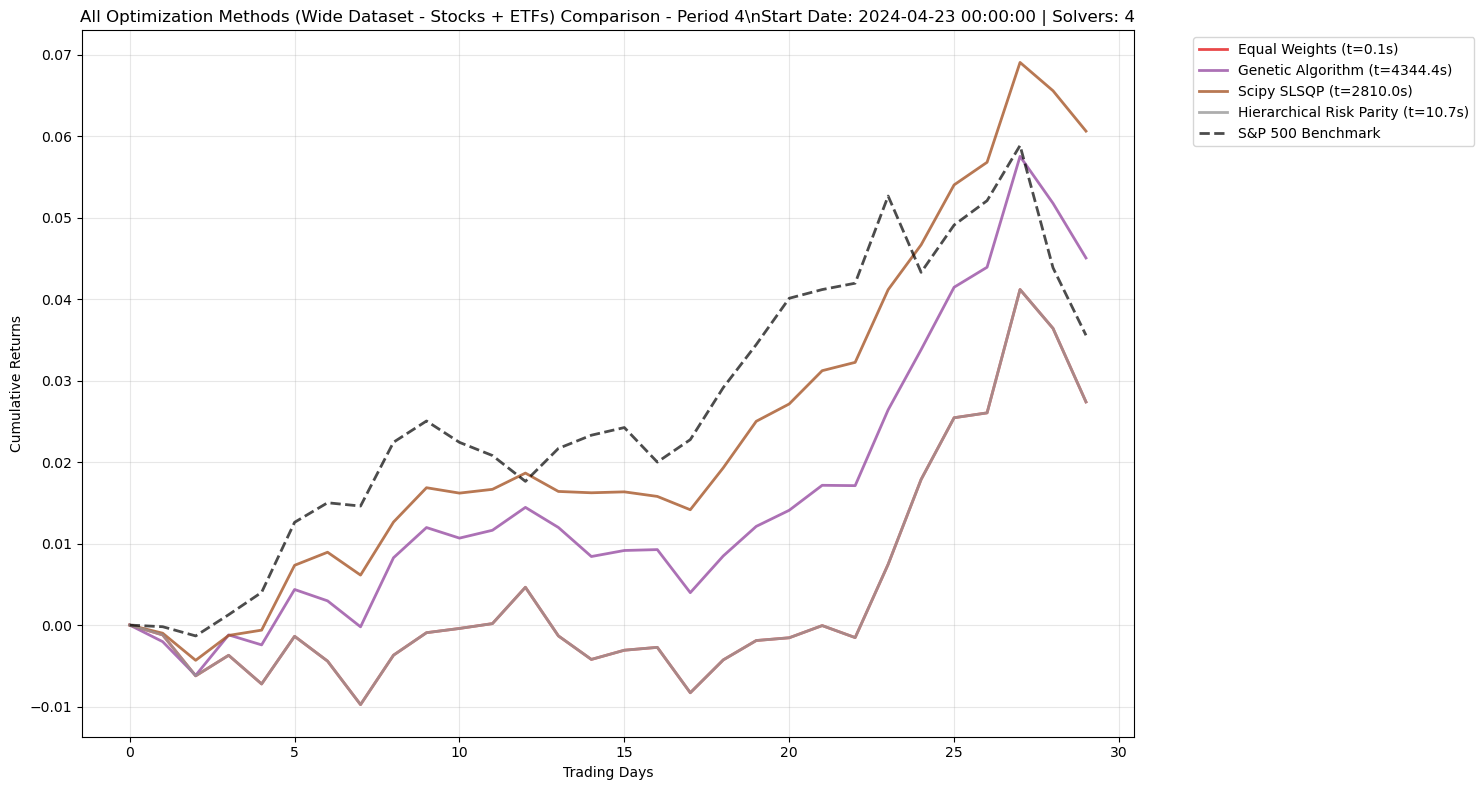

2025-10-16 08:17:35,357 - inspect_results_logger - INFO - Period 5: Loaded Equal Weights (exec_time: 0.10s)
2025-10-16 08:17:35,357 - inspect_results_logger - INFO - Period 5: Loaded Equal Weights (exec_time: 0.10s)
2025-10-16 08:17:35,359 - inspect_results_logger - INFO - Period 5: Loaded Genetic Algorithm (exec_time: 4341.59s)
2025-10-16 08:17:35,359 - inspect_results_logger - INFO - Period 5: Loaded Genetic Algorithm (exec_time: 4341.59s)
2025-10-16 08:17:35,362 - inspect_results_logger - INFO - Period 5: Loaded Scipy SLSQP (exec_time: 2153.29s)
2025-10-16 08:17:35,362 - inspect_results_logger - INFO - Period 5: Loaded Scipy SLSQP (exec_time: 2153.29s)


\nPeriod 4 Summary:
--------------------------------------------------
Equal Weights            :   0.0274 (  0.10s)
Genetic Algorithm        :   0.0451 (4344.37s)
Scipy SLSQP              :   0.0606 (2809.98s)
Hierarchical Risk Parity :   0.0274 ( 10.72s)
Benchmark                :   0.0356



2025-10-16 08:17:35,364 - inspect_results_logger - INFO - Period 5: Loaded Hierarchical Risk Parity (exec_time: 11.24s)
2025-10-16 08:17:35,364 - inspect_results_logger - INFO - Period 5: Loaded Hierarchical Risk Parity (exec_time: 11.24s)


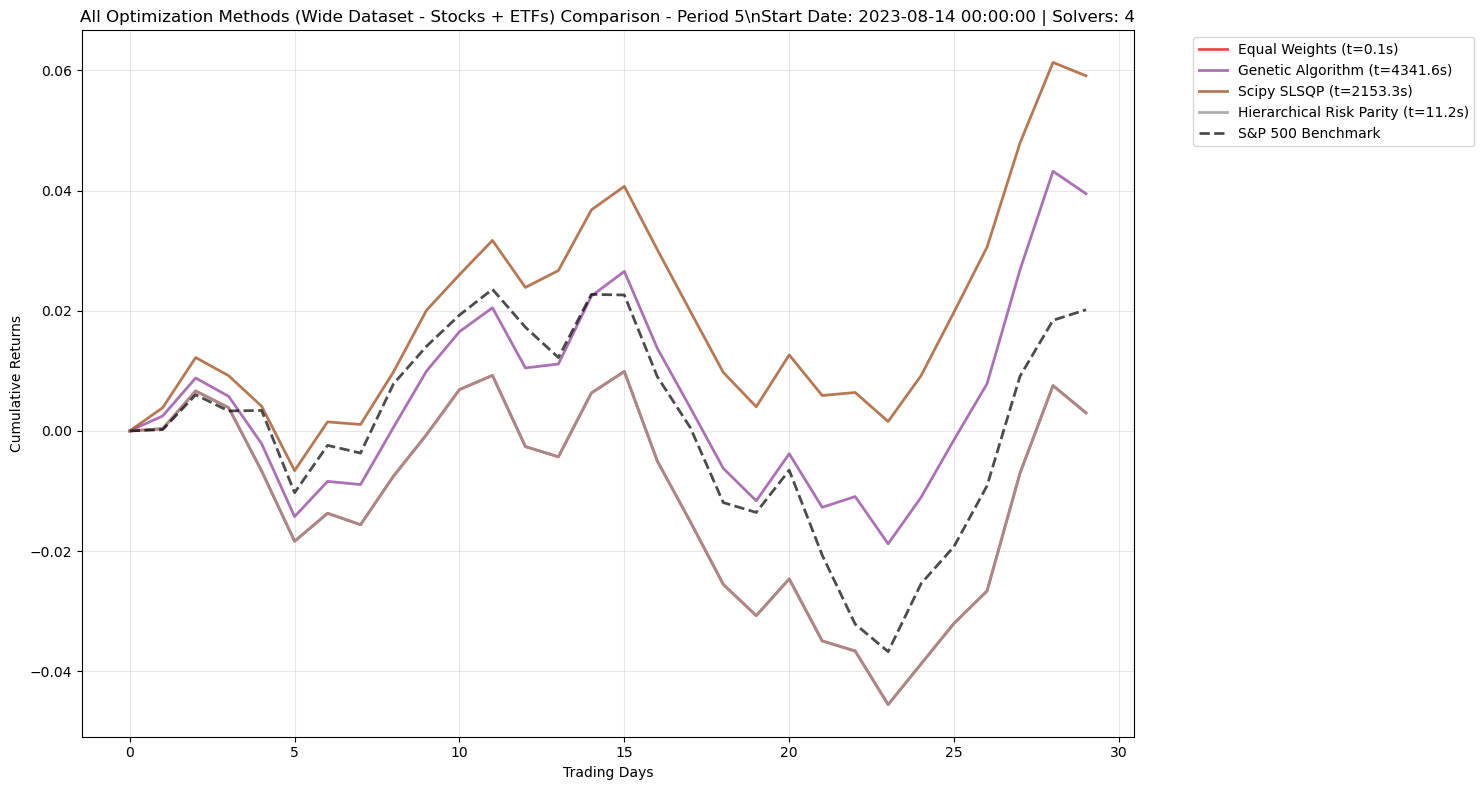

2025-10-16 08:17:35,452 - inspect_results_logger - INFO - Period 6: Loaded Equal Weights (exec_time: 0.11s)
2025-10-16 08:17:35,452 - inspect_results_logger - INFO - Period 6: Loaded Equal Weights (exec_time: 0.11s)
2025-10-16 08:17:35,454 - inspect_results_logger - INFO - Period 6: Loaded Genetic Algorithm (exec_time: 4354.40s)
2025-10-16 08:17:35,454 - inspect_results_logger - INFO - Period 6: Loaded Genetic Algorithm (exec_time: 4354.40s)


\nPeriod 5 Summary:
--------------------------------------------------
Equal Weights            :   0.0030 (  0.10s)
Genetic Algorithm        :   0.0395 (4341.59s)
Scipy SLSQP              :   0.0591 (2153.29s)
Hierarchical Risk Parity :   0.0030 ( 11.24s)
Benchmark                :   0.0202



2025-10-16 08:17:35,456 - inspect_results_logger - INFO - Period 6: Loaded Scipy SLSQP (exec_time: 2255.25s)
2025-10-16 08:17:35,456 - inspect_results_logger - INFO - Period 6: Loaded Scipy SLSQP (exec_time: 2255.25s)
2025-10-16 08:17:35,457 - inspect_results_logger - INFO - Period 6: Loaded Hierarchical Risk Parity (exec_time: 11.59s)
2025-10-16 08:17:35,457 - inspect_results_logger - INFO - Period 6: Loaded Hierarchical Risk Parity (exec_time: 11.59s)


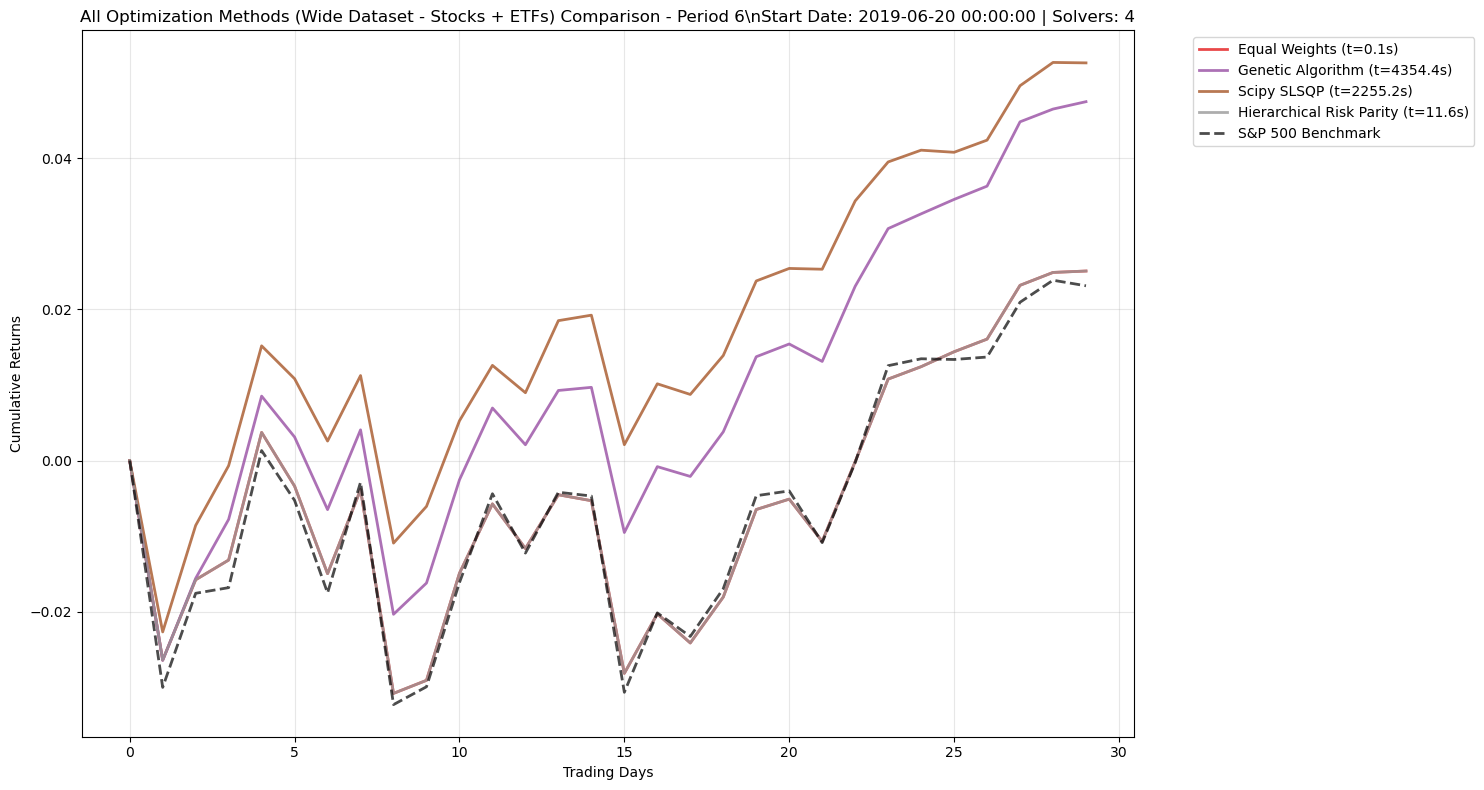

2025-10-16 08:17:35,541 - inspect_results_logger - INFO - Period 7: Loaded Equal Weights (exec_time: 0.17s)
2025-10-16 08:17:35,541 - inspect_results_logger - INFO - Period 7: Loaded Equal Weights (exec_time: 0.17s)
2025-10-16 08:17:35,543 - inspect_results_logger - INFO - Period 7: Loaded Genetic Algorithm (exec_time: 4365.19s)
2025-10-16 08:17:35,543 - inspect_results_logger - INFO - Period 7: Loaded Genetic Algorithm (exec_time: 4365.19s)
2025-10-16 08:17:35,544 - inspect_results_logger - INFO - Period 7: Loaded Scipy SLSQP (exec_time: 2310.39s)
2025-10-16 08:17:35,544 - inspect_results_logger - INFO - Period 7: Loaded Scipy SLSQP (exec_time: 2310.39s)
2025-10-16 08:17:35,546 - inspect_results_logger - INFO - Period 7: Loaded Hierarchical Risk Parity (exec_time: 9.23s)
2025-10-16 08:17:35,546 - inspect_results_logger - INFO - Period 7: Loaded Hierarchical Risk Parity (exec_time: 9.23s)


\nPeriod 6 Summary:
--------------------------------------------------
Equal Weights            :   0.0251 (  0.11s)
Genetic Algorithm        :   0.0475 (4354.40s)
Scipy SLSQP              :   0.0526 (2255.25s)
Hierarchical Risk Parity :   0.0251 ( 11.59s)
Benchmark                :   0.0231



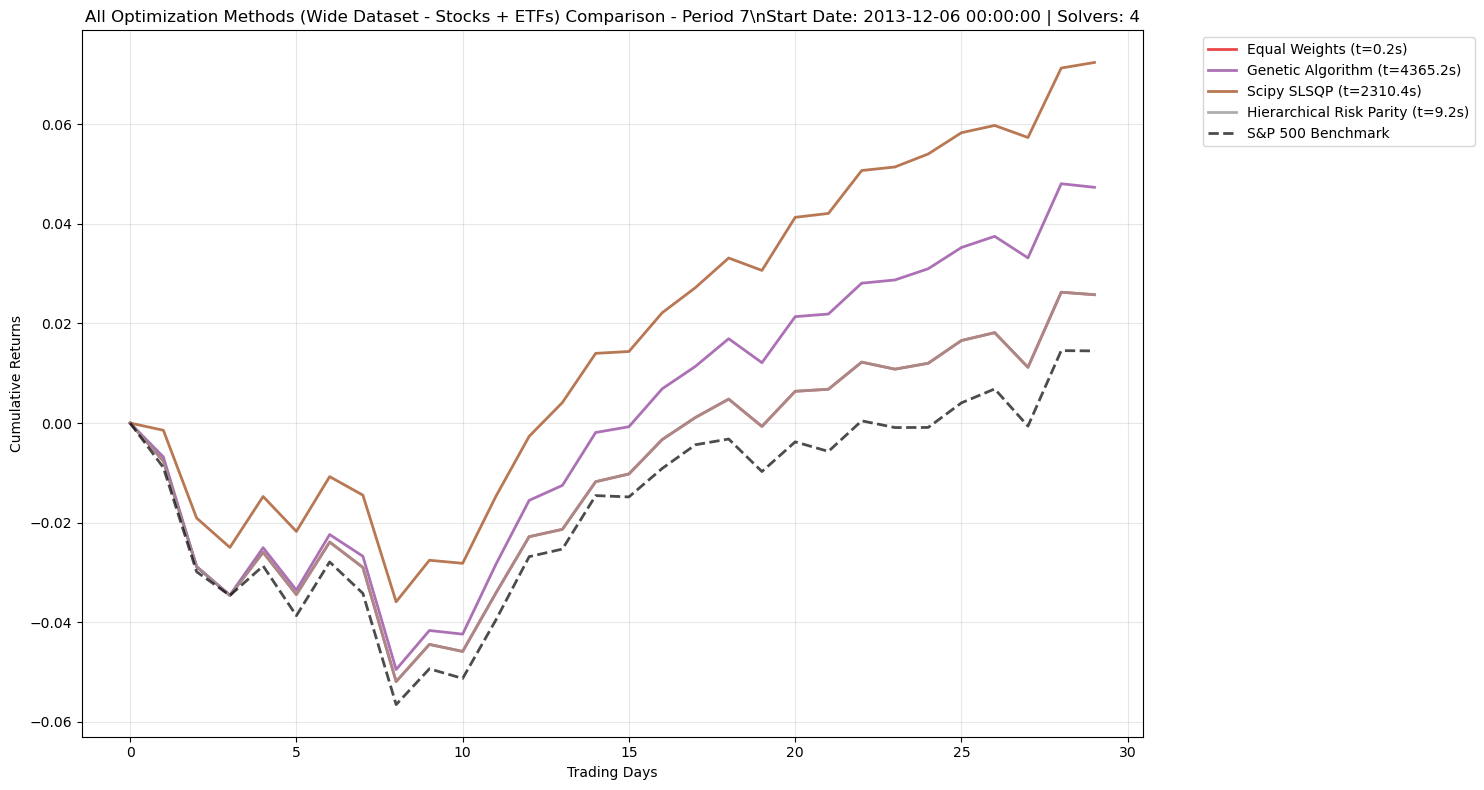

2025-10-16 08:17:35,634 - inspect_results_logger - INFO - Period 8: Loaded Equal Weights (exec_time: 0.10s)
2025-10-16 08:17:35,634 - inspect_results_logger - INFO - Period 8: Loaded Equal Weights (exec_time: 0.10s)
2025-10-16 08:17:35,636 - inspect_results_logger - INFO - Period 8: Loaded Genetic Algorithm (exec_time: 4373.41s)
2025-10-16 08:17:35,636 - inspect_results_logger - INFO - Period 8: Loaded Genetic Algorithm (exec_time: 4373.41s)
2025-10-16 08:17:35,638 - inspect_results_logger - INFO - Period 8: Loaded Scipy SLSQP (exec_time: 2633.58s)
2025-10-16 08:17:35,638 - inspect_results_logger - INFO - Period 8: Loaded Scipy SLSQP (exec_time: 2633.58s)
2025-10-16 08:17:35,641 - inspect_results_logger - INFO - Period 8: Loaded Hierarchical Risk Parity (exec_time: 10.08s)
2025-10-16 08:17:35,641 - inspect_results_logger - INFO - Period 8: Loaded Hierarchical Risk Parity (exec_time: 10.08s)


\nPeriod 7 Summary:
--------------------------------------------------
Equal Weights            :   0.0258 (  0.17s)
Genetic Algorithm        :   0.0473 (4365.19s)
Scipy SLSQP              :   0.0724 (2310.39s)
Hierarchical Risk Parity :   0.0258 (  9.23s)
Benchmark                :   0.0145



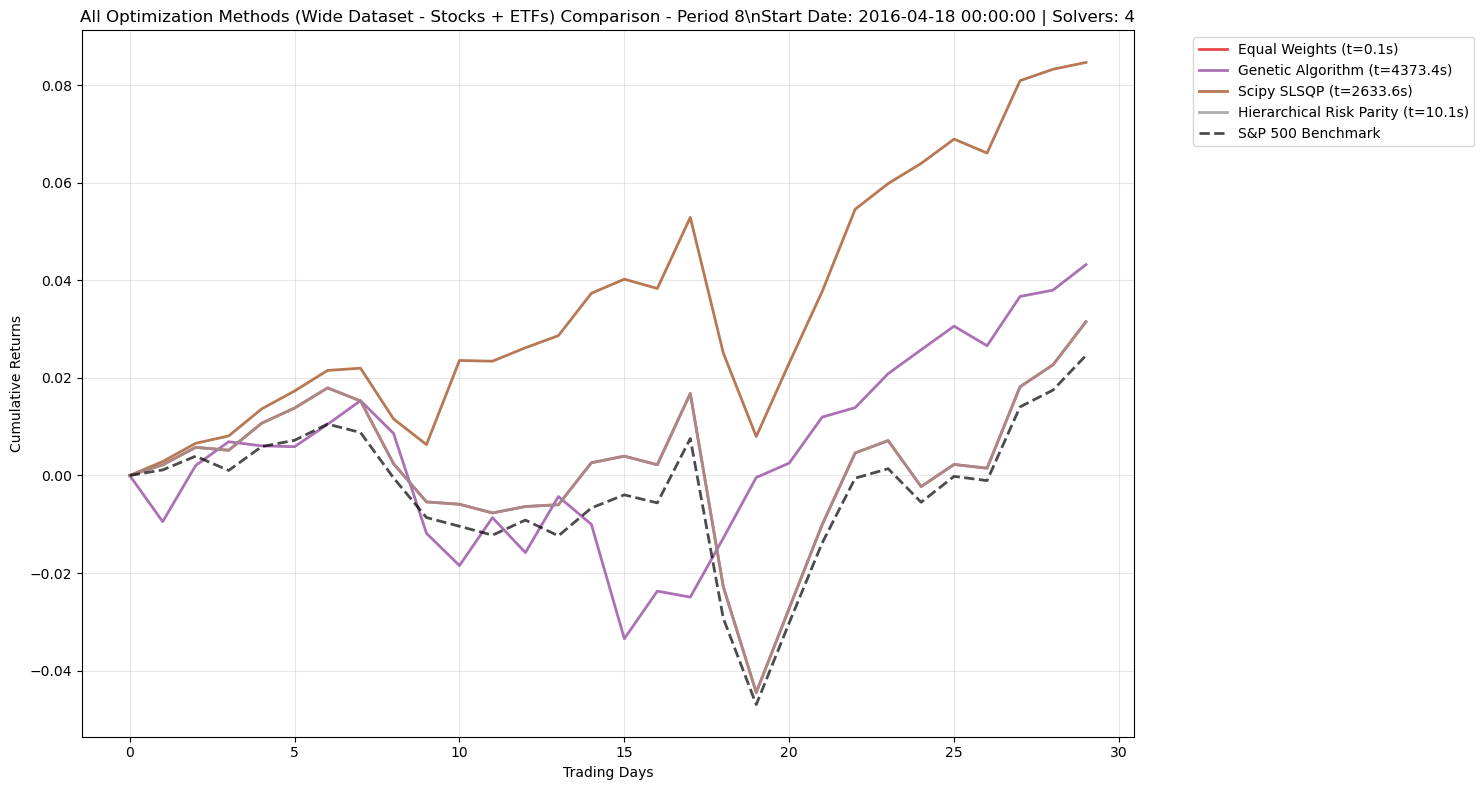

2025-10-16 08:17:35,728 - inspect_results_logger - INFO - Period 9: Loaded Equal Weights (exec_time: 0.10s)
2025-10-16 08:17:35,728 - inspect_results_logger - INFO - Period 9: Loaded Equal Weights (exec_time: 0.10s)
2025-10-16 08:17:35,731 - inspect_results_logger - INFO - Period 9: Loaded Genetic Algorithm (exec_time: 4366.15s)
2025-10-16 08:17:35,731 - inspect_results_logger - INFO - Period 9: Loaded Genetic Algorithm (exec_time: 4366.15s)
2025-10-16 08:17:35,733 - inspect_results_logger - INFO - Period 9: Loaded Scipy SLSQP (exec_time: 2095.26s)
2025-10-16 08:17:35,733 - inspect_results_logger - INFO - Period 9: Loaded Scipy SLSQP (exec_time: 2095.26s)
2025-10-16 08:17:35,735 - inspect_results_logger - INFO - Period 9: Loaded Hierarchical Risk Parity (exec_time: 11.83s)
2025-10-16 08:17:35,735 - inspect_results_logger - INFO - Period 9: Loaded Hierarchical Risk Parity (exec_time: 11.83s)


\nPeriod 8 Summary:
--------------------------------------------------
Equal Weights            :   0.0315 (  0.10s)
Genetic Algorithm        :   0.0432 (4373.41s)
Scipy SLSQP              :   0.0846 (2633.58s)
Hierarchical Risk Parity :   0.0315 ( 10.08s)
Benchmark                :   0.0246



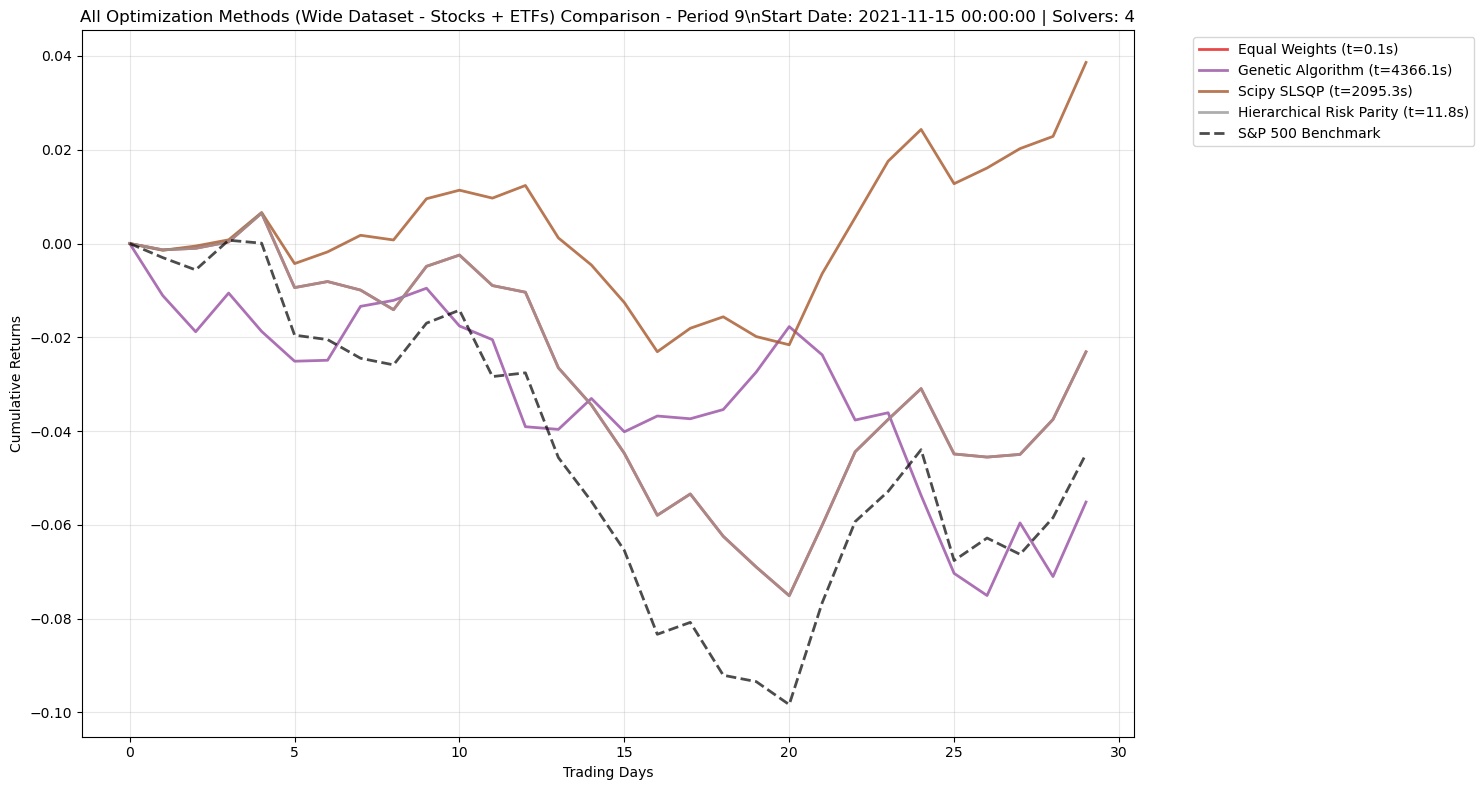

\nPeriod 9 Summary:
--------------------------------------------------
Equal Weights            :  -0.0231 (  0.10s)
Genetic Algorithm        :  -0.0551 (4366.15s)
Scipy SLSQP              :   0.0386 (2095.26s)
Hierarchical Risk Parity :  -0.0231 ( 11.83s)
Benchmark                :  -0.0449

\n====================================================================================================
COMPREHENSIVE PERFORMANCE SUMMARY - All Methods (Wide Dataset - Stocks + ETFs)


,Solver,Periods,Avg_Return,Std_Return,Min_Return,Max_Return,Avg_Time,Std_Time,Success_Rate
2,Scipy SLSQP,10,0.0560,0.0340,-0.0287,0.1029,2411.1371,456.4414,100.0
1,Genetic Algorithm,10,0.0256,0.0430,-0.0551,0.0827,4358.0010,9.1373,100.0
0,Equal Weights,10,0.0077,0.0353,-0.0786,0.0543,0.1088,0.0190,100.0
3,Hierarchical Risk Parity,10,0.0077,0.0353,-0.0786,0.0543,10.8190,0.7192,100.0


\nPerformance Analysis:
--------------------------------------------------
Methods compared: 4
Best performer: Scipy SLSQP (avg return: 0.0560)
Fastest method: Equal Weights (0.11s)
Most reliable: Equal Weights (100.0%)


In [64]:
# Comprehensive comparison of ALL optimization methods for Wide Dataset including Quantum
wide_dataset_solvers = [
    {'path_template': '../../results/sharpe_optimization/results_ew_{}.pkl', 'name': 'Equal Weights'},
    {'path_template': '../../results/sharpe_optimization/results_ga_{}.pkl', 'name': 'Genetic Algorithm'},
    {'path_template': '../../results/sharpe_optimization/results_bf_{}.pkl', 'name': 'Scipy SLSQP'},
    {'path_template': '../../results/sharpe_optimization/results_hrp_{}.pkl', 'name': 'Hierarchical Risk Parity'},
]

n_periods = parameters['n_periods']
multi_comparison(wide_dataset_solvers, n_periods, "All Optimization Methods (Wide Dataset - Stocks + ETFs)")

# Generate comprehensive performance summary
print("\\n" + "="*100)
print("COMPREHENSIVE PERFORMANCE SUMMARY - All Methods (Wide Dataset - Stocks + ETFs)")
print("="*100)
summary_df = performance_summary(wide_dataset_solvers, n_periods)
if not summary_df.empty:
    # Sort by average return for better readability
    summary_df_sorted = summary_df.sort_values('Avg_Return', ascending=False)
    display(summary_df_sorted)
    
    # Performance analysis
    print("\\nPerformance Analysis:")
    print("-" * 50)
    print(f"Methods compared: {len(summary_df)}")
    print(f"Best performer: {summary_df_sorted.iloc[0]['Solver']} (avg return: {summary_df_sorted.iloc[0]['Avg_Return']:.4f})")
    print(f"Fastest method: {summary_df.loc[summary_df['Avg_Time'].idxmin(), 'Solver']} ({summary_df['Avg_Time'].min():.2f}s)")
    print(f"Most reliable: {summary_df.loc[summary_df['Success_Rate'].idxmax(), 'Solver']} ({summary_df['Success_Rate'].max():.1f}%)")
else:
    print("No summary data available")

### Experiment 2: Synthetic Dataset with 1000 securities 

In [65]:
source_synth_path = '../../data/synthetic_close.pkl'

In [66]:
source_synth = pd.read_pickle(source_synth_path)
source_synth.head()

,ds,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,FUND_906_RATIO,CMWQ,UAA_VOL,XEB,ETF_609,STOCK_442,ECFE,REIT_677_PRICE,OVDJ,QMCFQ
0,2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,...,18.107629,75.492461,129.462925,125.937036,87.798646,98.343111,125.783745,17.166407,145.878215,190.952276
1,2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,...,18.030430,75.850052,128.858985,124.957257,87.413089,98.193005,125.538872,17.047364,145.654602,191.300773
2,2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,...,17.971160,76.258827,128.802213,124.441944,87.940231,97.989877,125.854862,16.999914,146.992259,191.298014
3,2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,...,17.821023,76.472465,129.117381,124.334951,87.966434,97.917770,125.800167,17.030518,148.804873,190.944464
4,2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,...,17.680604,76.430398,129.274692,124.344211,88.868399,97.893132,126.111993,17.036943,151.627367,189.739391


In [67]:
print(source_synth.shape)
has_any_nan = source_synth.isnull().values.any()
print('Any NaN in source_synth:', has_any_nan)
source_synth.head()

(3521, 1201)
Any NaN in source_synth: False


,ds,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,FUND_906_RATIO,CMWQ,UAA_VOL,XEB,ETF_609,STOCK_442,ECFE,REIT_677_PRICE,OVDJ,QMCFQ
0,2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,...,18.107629,75.492461,129.462925,125.937036,87.798646,98.343111,125.783745,17.166407,145.878215,190.952276
1,2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,...,18.030430,75.850052,128.858985,124.957257,87.413089,98.193005,125.538872,17.047364,145.654602,191.300773
2,2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,...,17.971160,76.258827,128.802213,124.441944,87.940231,97.989877,125.854862,16.999914,146.992259,191.298014
3,2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,...,17.821023,76.472465,129.117381,124.334951,87.966434,97.917770,125.800167,17.030518,148.804873,190.944464
4,2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,...,17.680604,76.430398,129.274692,124.344211,88.868399,97.893132,126.111993,17.036943,151.627367,189.739391


In [68]:
df_synth = source_synth
df_synth.set_index('ds', inplace=True)
days_to_avg = parameters['days_to_avg']
display(df_synth.head())
has_any_nan = source_synth.isnull().values.any()
print('Any NaN in source_synth:', has_any_nan)
print(f'initial date: {df_synth.iloc[days_to_avg+1, :].index}')

,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,FUND_906_RATIO,CMWQ,UAA_VOL,XEB,ETF_609,STOCK_442,ECFE,REIT_677_PRICE,OVDJ,QMCFQ
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,18.107629,75.492461,129.462925,125.937036,87.798646,98.343111,125.783745,17.166407,145.878215,190.952276
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,18.030430,75.850052,128.858985,124.957257,87.413089,98.193005,125.538872,17.047364,145.654602,191.300773
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,17.971160,76.258827,128.802213,124.441944,87.940231,97.989877,125.854862,16.999914,146.992259,191.298014
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,17.821023,76.472465,129.117381,124.334951,87.966434,97.917770,125.800167,17.030518,148.804873,190.944464
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,17.680604,76.430398,129.274692,124.344211,88.868399,97.893132,126.111993,17.036943,151.627367,189.739391


Any NaN in source_synth: False
initial date: Index(['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK',
       ...
       'FUND_906_RATIO', 'CMWQ', 'UAA_VOL', 'XEB', 'ETF_609', 'STOCK_442',
       'ECFE', 'REIT_677_PRICE', 'OVDJ', 'QMCFQ'],
      dtype='object', length=1200)


<Axes: xlabel='ds'>

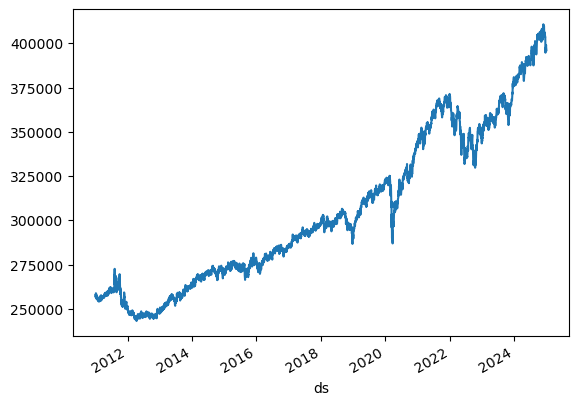

In [69]:
df_synth.sum(axis=1).plot()

Resetting parameters. The total cost of synthetic stocks may require higher capital.

In [70]:
parameters = {
    'population_size': 100,
    'num_generations': 100,
    'mutation_rate': 0.1,
    'elitism': 0.1,
    'n_periods': 10,
    'days_to_avg': 30,
    'days_to_opt': 30,
    'initial_capital': 10_000_000,
}

In [71]:
data_gen = generate_data(df_synth, benchmark, days_to_avg=30, days_to_opt=30, seed=SEED)
df, df_b = next(data_gen)
df.tail()

,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,FUND_906_RATIO,CMWQ,UAA_VOL,XEB,ETF_609,STOCK_442,ECFE,REIT_677_PRICE,OVDJ,QMCFQ
ds,,,,,,,,,,,,,,,,,,,,,
2014-02-18,35.987545,17.094862,31.480751,17.727919,68.256264,68.660004,40.423801,29.707829,52.764717,54.520000,...,16.491393,51.196646,294.039336,330.510589,99.858985,139.814198,155.204728,18.475895,70.671243,284.468809
2014-02-19,36.503075,16.824974,31.343287,17.502872,68.809998,67.989998,40.692089,29.282701,52.530193,54.470001,...,16.396301,50.914023,296.626714,331.025651,102.022585,139.793969,156.240165,18.340819,71.446138,283.258807
2014-02-20,37.383987,16.630224,31.496935,17.651846,68.909180,68.480003,40.557964,29.407299,52.778519,54.900002,...,16.367533,50.758845,299.762204,331.668085,103.939102,139.940008,157.052182,18.483789,72.910436,281.710411
2014-02-21,36.764088,16.445498,31.391796,17.705730,69.256287,68.220001,40.337021,29.312025,52.564671,55.400002,...,16.329645,50.457478,301.650829,332.112890,105.442671,140.278673,157.946203,18.652996,73.970279,279.684075
2014-02-24,37.031612,16.517513,31.521198,17.506042,69.380234,68.769997,40.210762,29.436628,52.978558,54.470001,...,16.347139,50.080086,301.413926,332.257976,107.335604,140.353310,158.403707,18.651485,75.323218,278.148884


#### Equal Weights Baseline

In [ ]:
results_path_ew_synth = '../../results/sharpe_optimization/results_synth_ew_{}.pkl'
_ = run_experiment(results_path_ew_synth, df_synth, benchmark, opt_fun_ew, parameters)

#### GA Synth

initial date: 2014-01-13 00:00:00


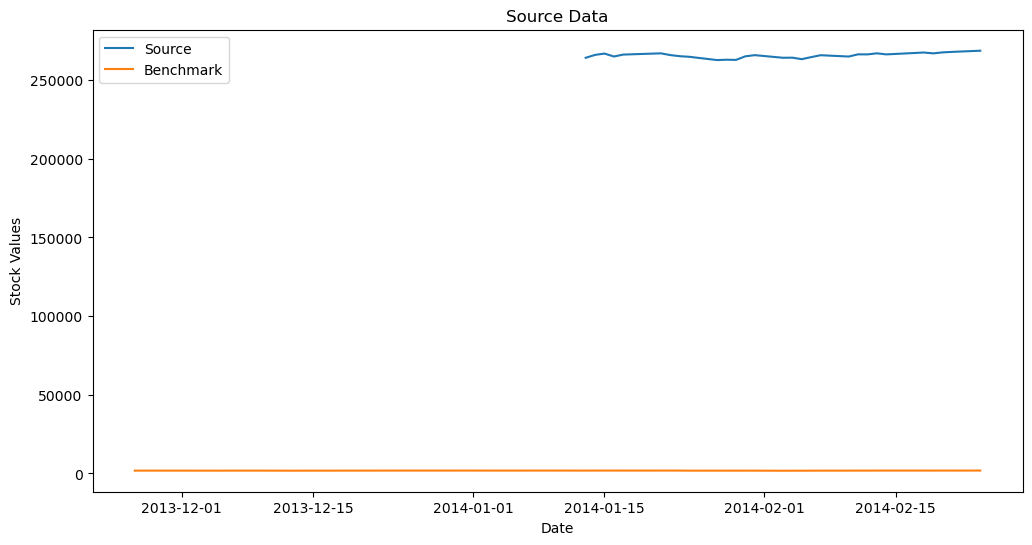

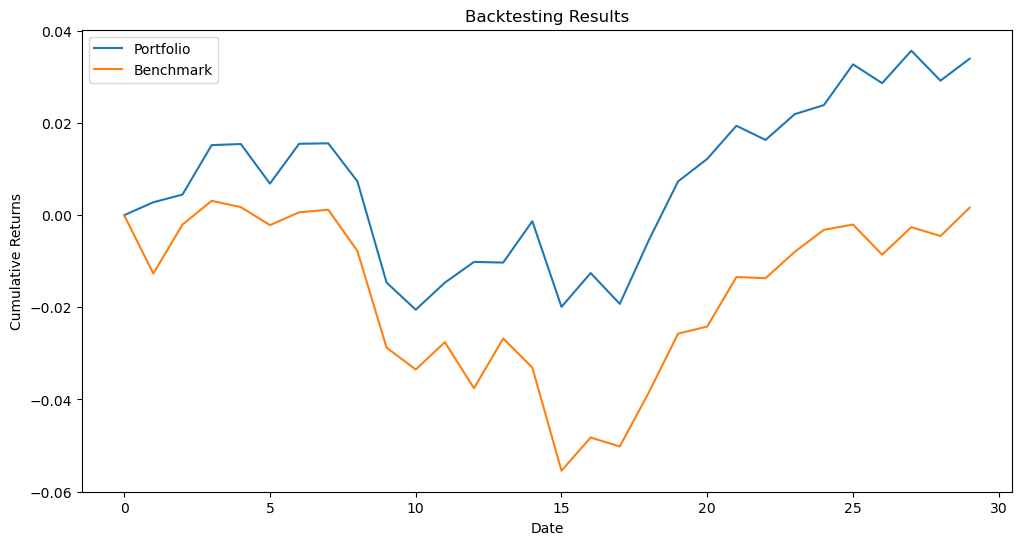

Dictionary pickled and saved to ../../results/sharpe_optimization/results_synth_ga_0.pkl
initial date: 2023-02-03 00:00:00


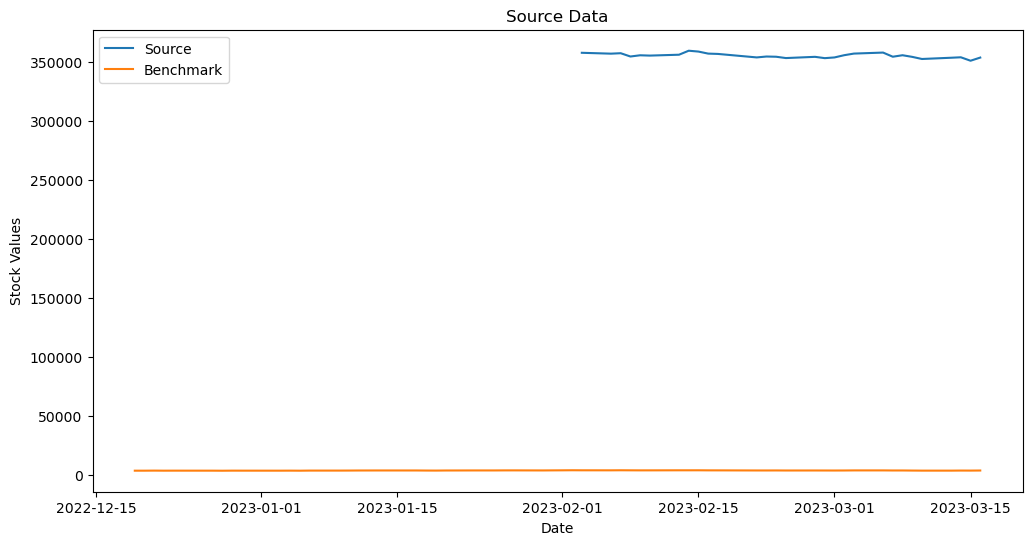

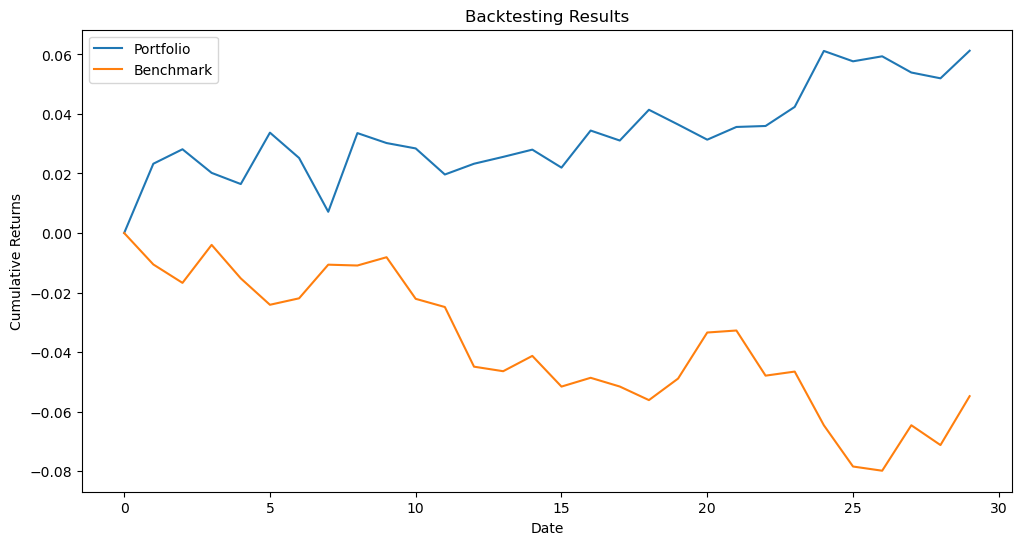

Dictionary pickled and saved to ../../results/sharpe_optimization/results_synth_ga_1.pkl
initial date: 2024-03-04 00:00:00


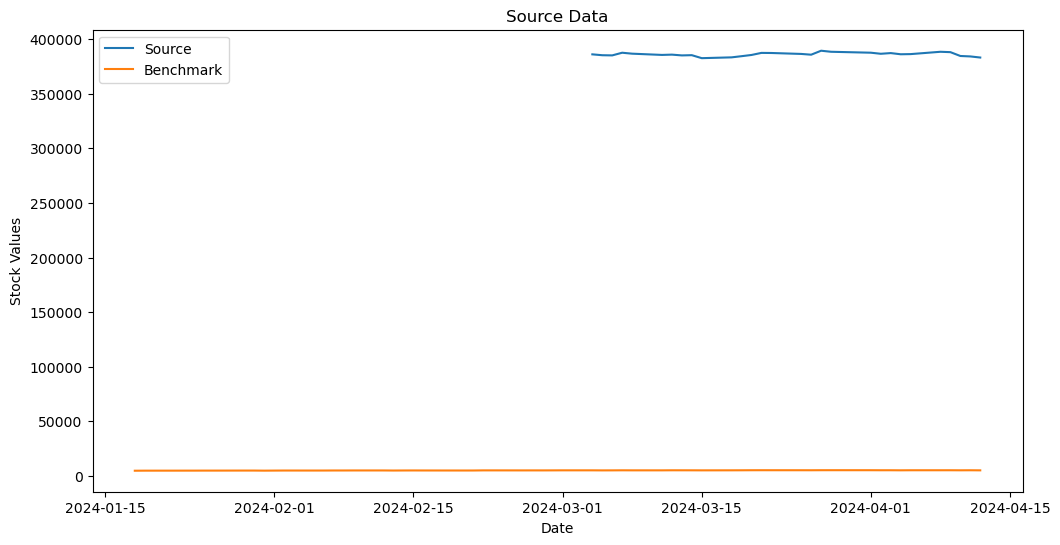

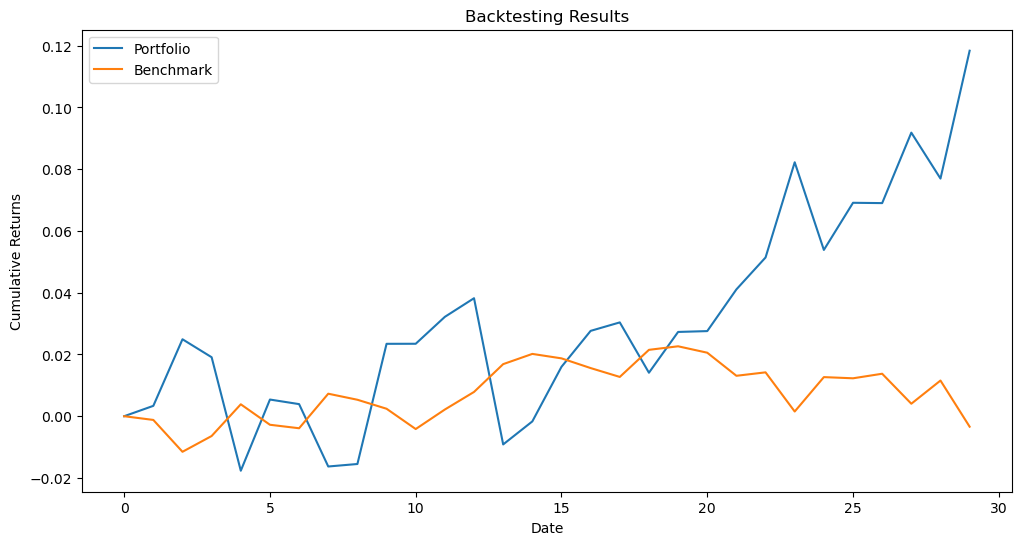

Dictionary pickled and saved to ../../results/sharpe_optimization/results_synth_ga_2.pkl
initial date: 2021-09-22 00:00:00


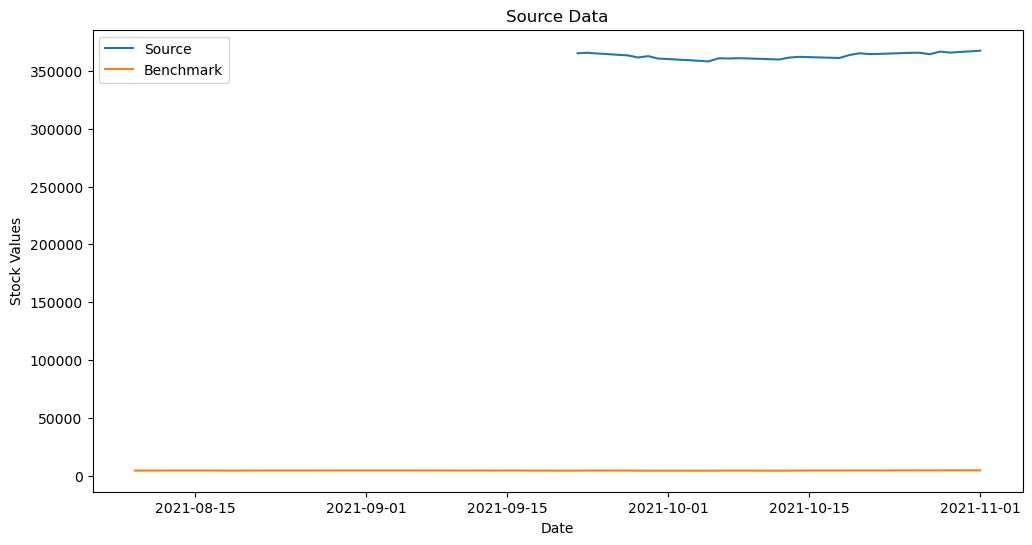

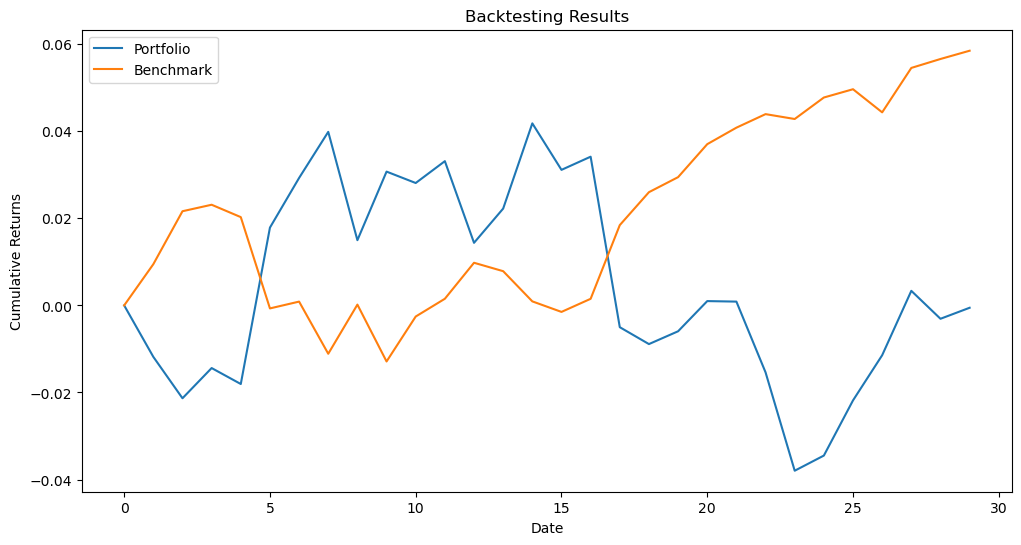

Dictionary pickled and saved to ../../results/sharpe_optimization/results_synth_ga_3.pkl
initial date: 2024-06-06 00:00:00


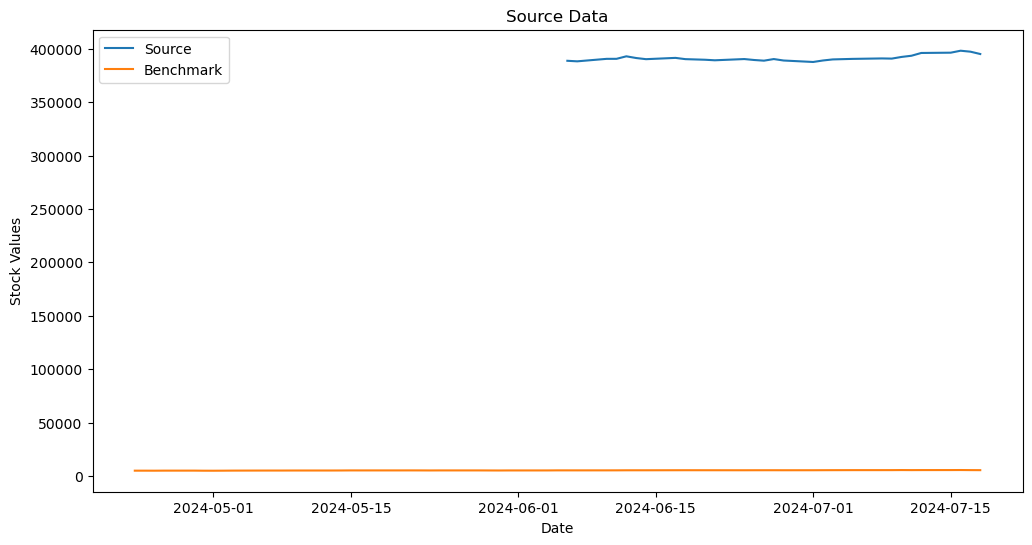

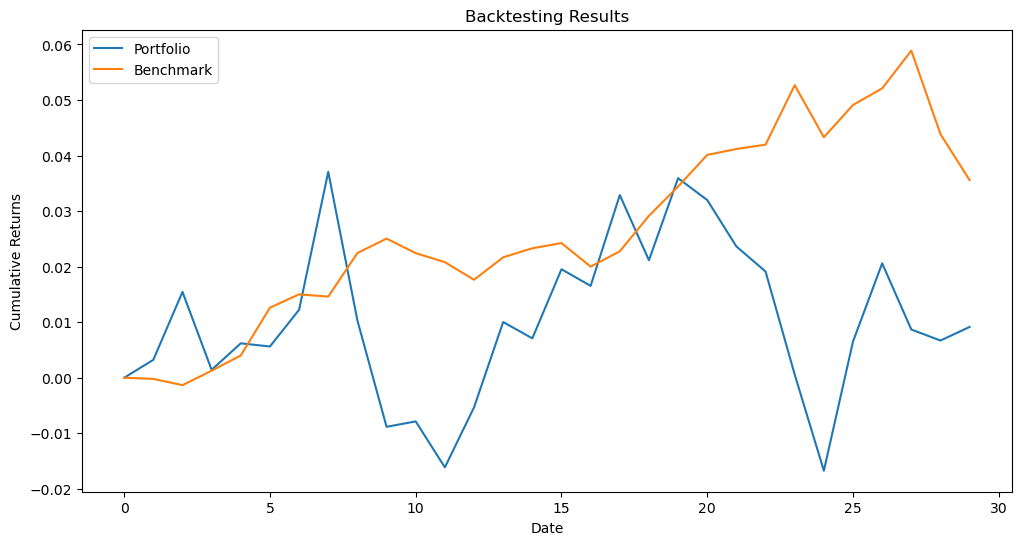

Dictionary pickled and saved to ../../results/sharpe_optimization/results_synth_ga_4.pkl
initial date: 2023-09-27 00:00:00


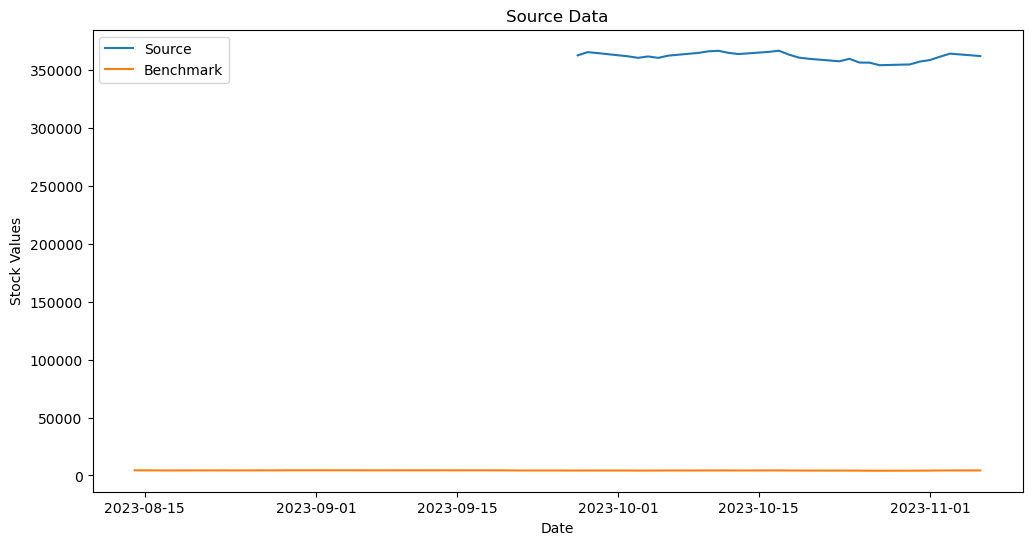

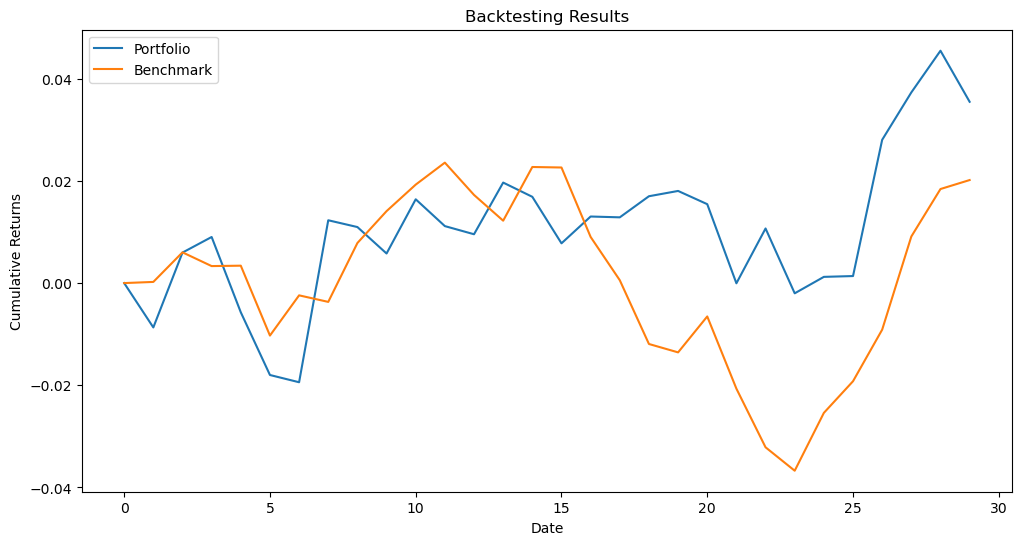

Dictionary pickled and saved to ../../results/sharpe_optimization/results_synth_ga_5.pkl
initial date: 2019-08-05 00:00:00


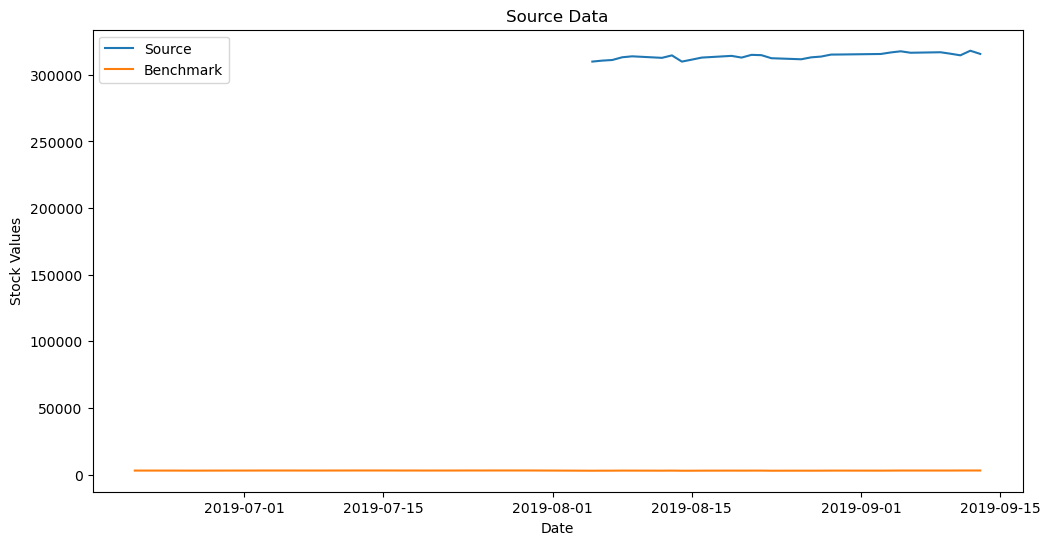

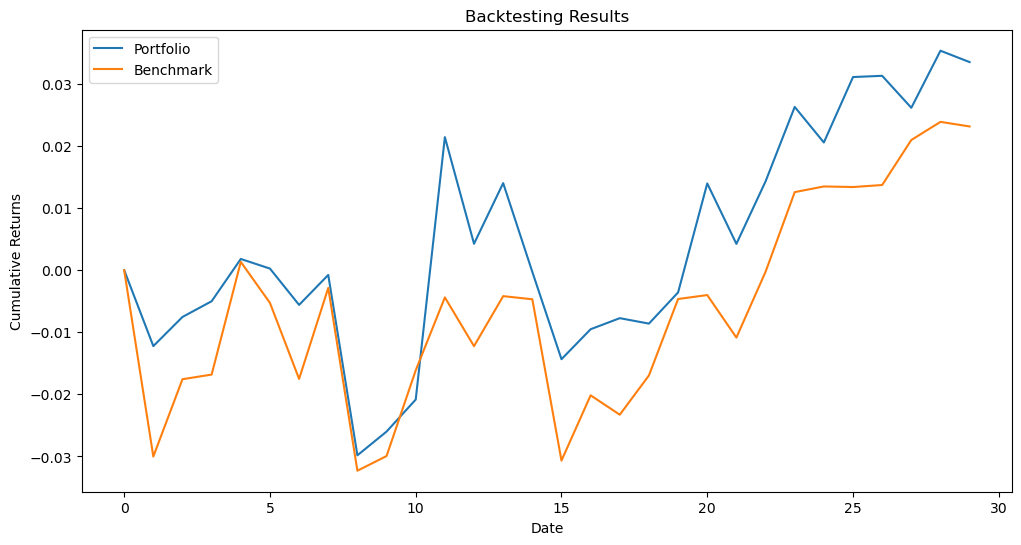

Dictionary pickled and saved to ../../results/sharpe_optimization/results_synth_ga_6.pkl
initial date: 2014-01-23 00:00:00


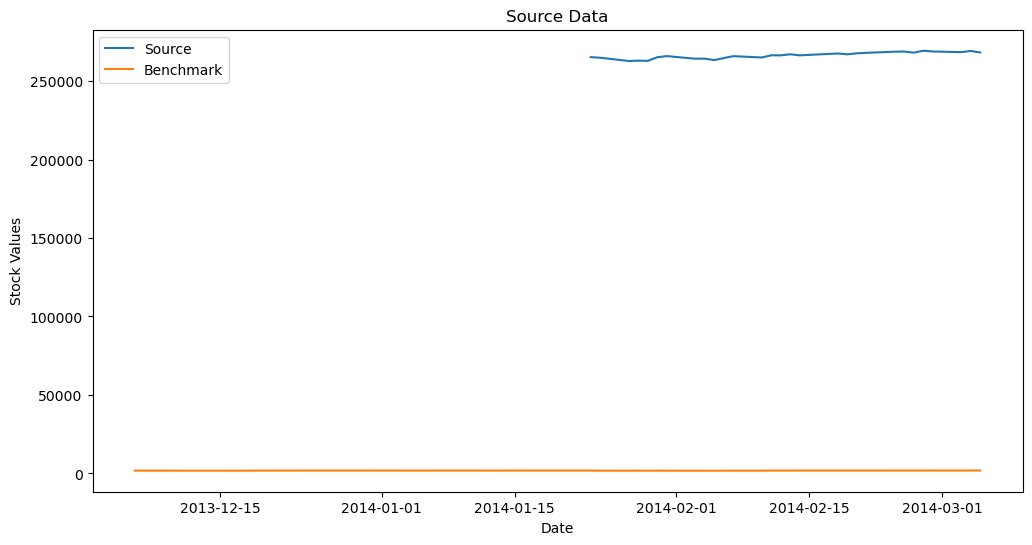

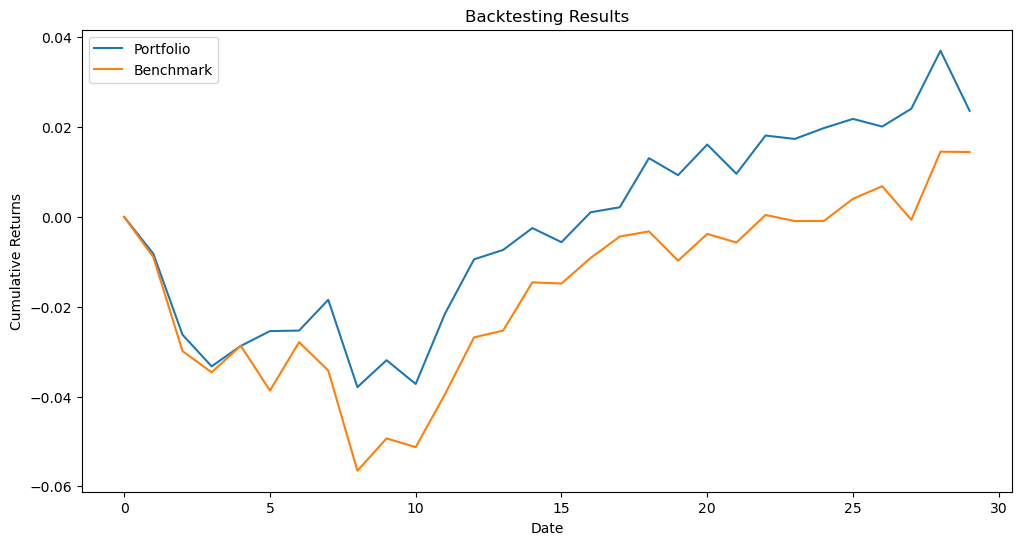

Dictionary pickled and saved to ../../results/sharpe_optimization/results_synth_ga_7.pkl
initial date: 2016-06-01 00:00:00


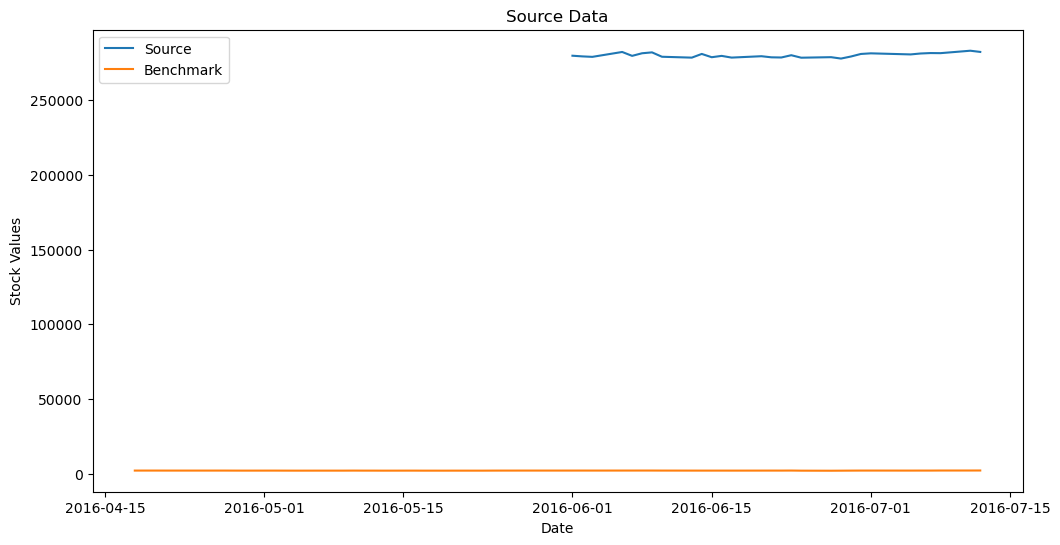

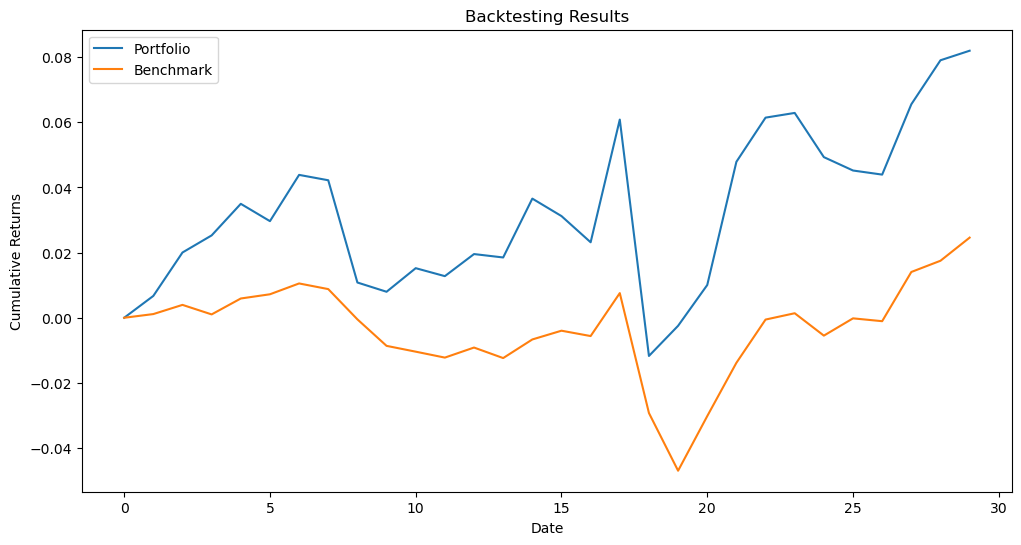

Dictionary pickled and saved to ../../results/sharpe_optimization/results_synth_ga_8.pkl
initial date: 2021-12-30 00:00:00


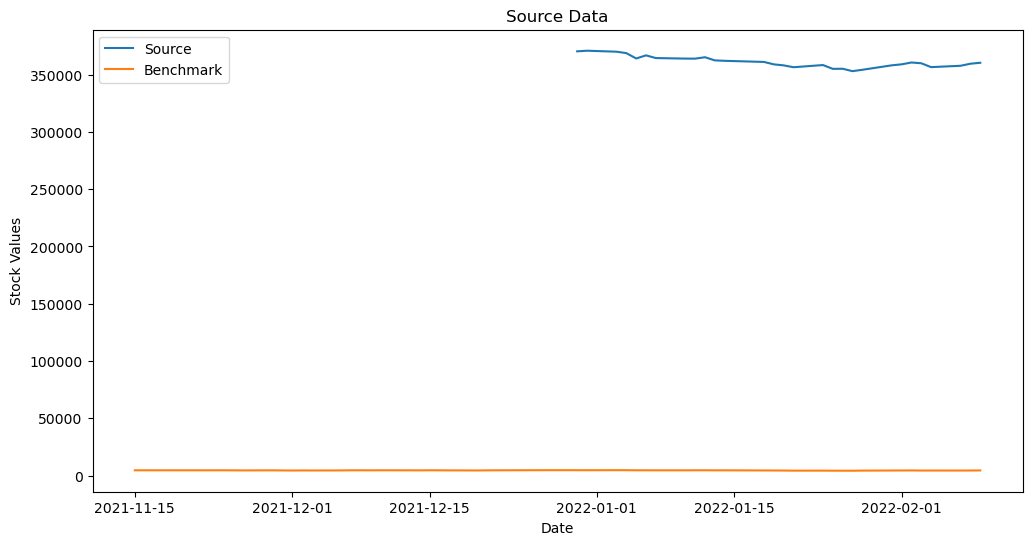

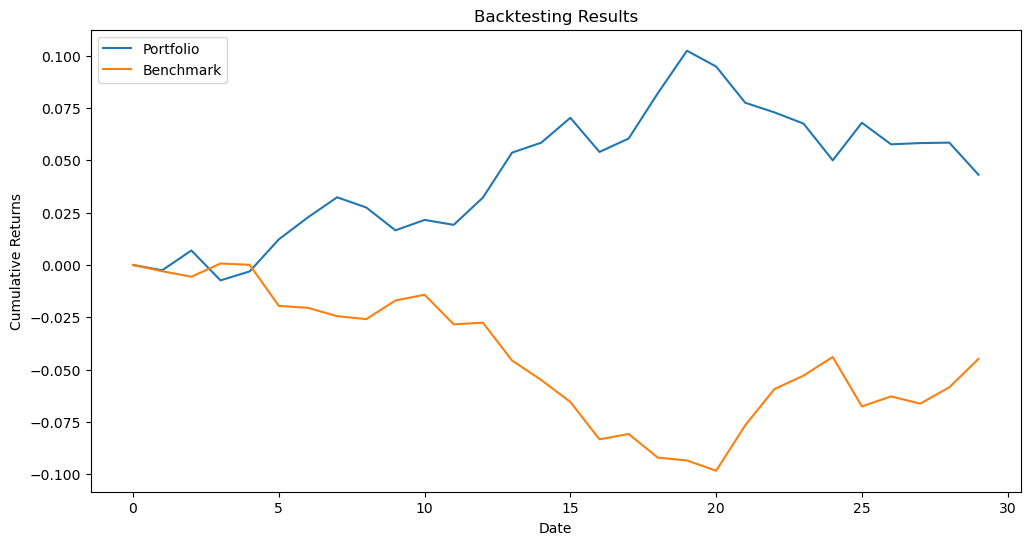

Dictionary pickled and saved to ../../results/sharpe_optimization/results_synth_ga_9.pkl


In [ ]:
results_path_ga_synth = '../../results/sharpe_optimization/results_synth_ga_{}.pkl'
_ = run_experiment(results_path_ga_synth, df_synth, benchmark, opt_fun_ga, parameters)

#### Scipy SLSQP Synth

#### Riskfolio (HRP) Synth

In [ ]:
results_path_hrp_synth = '../../results/sharpe_optimization_diversified/results_synth_hrp_{}.pkl'
_ = run_experiment(results_path_hrp_synth, df_synth, benchmark, opt_fun_hrp, parameters)

#### Synthetic Dataset Method Comparison

In [ ]:
# Comprehensive comparison of ALL optimization methods for Synthetic Dataset
synth_dataset_solvers = [
    {'path_template': '../../results/sharpe_optimization/results_synth_ew_{}.pkl', 'name': 'Equal Weights'},
    {'path_template': '../../results/sharpe_optimization/results_synth_ga_{}.pkl', 'name': 'Genetic Algorithm'},
    {'path_template': '../../results/sharpe_optimization/results_synth_bf_{}.pkl', 'name': 'Scipy SLSQP'},
    {'path_template': '../../results/sharpe_optimization/results_synth_hrp_{}.pkl', 'name': 'Hierarchical Risk Parity'},
]

n_periods = parameters['n_periods']
multi_comparison(synth_dataset_solvers, n_periods, "All Optimization Methods (Synthetic Dataset)")

# Generate comprehensive performance summary
print("\n" + "="*100)
print("COMPREHENSIVE PERFORMANCE SUMMARY - All Methods (Synthetic Dataset)")
print("="*100)
summary_df_synth = performance_summary(synth_dataset_solvers, n_periods)
if not summary_df_synth.empty:
    # Sort by average return for better readability
    summary_df_synth_sorted = summary_df_synth.sort_values('Avg_Return', ascending=False)
    display(summary_df_synth_sorted)
    
    # Performance analysis
    print("\nPerformance Analysis:")
    print("-" * 50)
    print(f"Methods compared: {len(summary_df_synth)}")
    print(f"Best performer: {summary_df_synth_sorted.iloc[0]['Solver']} (avg return: {summary_df_synth_sorted.iloc[0]['Avg_Return']:.4f})")
    print(f"Fastest method: {summary_df_synth.loc[summary_df_synth['Avg_Time'].idxmin(), 'Solver']} ({summary_df_synth['Avg_Time'].min():.2f}s)")
    print(f"Most reliable: {summary_df_synth.loc[summary_df_synth['Success_Rate'].idxmax(), 'Solver']} ({summary_df_synth['Success_Rate'].max():.1f}%)")
else:
    print("No summary data available")